# **IA para DEVs - 8IADT - Fase 1**

## **Tech Chalenge - Diagnóstico de Doenças**
### **Grupo 40**
### **Integrantes**:
- Rodrigo de Araújo Rosa
- Elias Maximiano da Silva
- Fábia Gomes de jesus
- Danilo Pereira

### **Desafio**
Um grande hospital universitário busca implementar um sistema inteligente de suporte ao diagnóstico, capaz de ajudar médicos e equipes clínicas na análise inicial de exames e no processamento de dados médicos.

Com um volume crescente de pacientes e exames, como radiografias, tomografias, ressonâncias e prontuários digitalizados, o hospital precisa de soluções que acelerem a triagem e apoiem as decisões médicas, reduzindo erros e otimizando o tempo dos profissionais.

Nesta primeira fase, o desafio é criar a base do sistema de IA focado em machine learning, permitindo que resultados de exames sejam analisados automaticamente e destacando informações relevantes para o diagnóstico.

### **Objetivo**
Construir uma solução inicial com foco em IA para processamento de exames médicos e documentos clínicos, aplicando fundamentos essenciais de IA, Machine Learning e Visão Computacional.

# INSTALAÇÃO, IMPORTAÇÃO E CONFIGURAÇÃO DE BIBLIOTECAS

In [ ]:
!pip install dtreeviz

In [ ]:
pip install imbalanced-learn

In [3]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sb
import dtreeviz
import warnings
import logging
import yellowbrick
import shap

# Silencia warnings do Python
warnings.filterwarnings("ignore")

# Silencia logs do Matplotlib
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

print('Bibliotecas importadas e configurações realizadas com sucesso.')

Bibliotecas importadas e configurações realizadas com sucesso.


# 1. ANÁLISE EXPLORATÓRIA DOS DADOS (EDA)

In [4]:
# Carregando do dataset
#dataset = 'diabetes.csv' # para rodar no colab. Colocar no diretório raiz do projeto
dataset = '../data/raw/diabetes.csv' # para rodar localmente. Colocar no diretório data/raw
try:
    df = pd.read_csv(dataset)
    print('Base de dados carregada com sucesso.')
except FileNotFoundError:
    print(f"Dataset '{dataset}' não encontrado. Certifique de ter copiado para o diretório correto")
except pd.errors.EmptyDataError:
    print(f"Dataset '{dataset}' está vazio.")
except pd.errors.ParserError:
    print(f"Erro ao fazer o parse do dataset '{dataset}'. Verifique o formato do arquivo.")
except Exception as e:
    print(f"Erro inesperado: {e}")

Base de dados carregada com sucesso.


In [5]:
# Verificando as dimensões do dataset
shape = df.shape
print(f"O dataset possui {shape[0]} linhas e {shape[1]} colunas.")

O dataset possui 768 linhas e 9 colunas.


In [6]:
# Analisando as 5 primeiras linhas do dataset
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
# Analisando as informações do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### **Inferência sobre o dataset**

Originário do Instituto Nacional de Diabetes e Doenças Digestivas dos Estados Unidos (National Institute of Diabetes and Digestive and Kidney Diseases - NIH), este dataset tem o objetivo de prever, com base em medidas diagnósticas, se um paciente possui diabetes.

O dataset considera apenas mulheres com pelo menos 21 anos de idade e com ascendência indígena Pima.

No dataset temos as variáveis abaixo:
- **Pregnancies**: número de vezes que a paciente engravidou
- **Glucose**: concentração de glicose plasmática após 2 horas em um teste de tolerancia a glicose (OGTT - Oral Glucose Tolerance Test)
  - Menor que 140: normal
  - De 140 a 199: pré disposição a dibetes
  - Maior/igual 200: presença de diabetes
  > Referência NIH: *[Glucose Tolerance Test](https://www.ncbi.nlm.nih.gov/books/NBK532915/#:~:text=Results%2C%20Reporting%2C%20and%20Critical%20Findings&text=The%20results%20of%20the%20OGTT,least%20200%20mg/dL:%20diabetes)*
- **BloodPressure**: pressão arterial diastólica (mm Hg)
  - **Observação**: nos chamou a atenção que os dados imputados são referentes a pressão diastólica apenas, no entanto, pesquisando sobre o assunto, a pressão sistólica também é considerada (*[Aqui um artigo interessante sobre diabetes e hipertenção](https://diabetesjournals.org/care/article/40/9/1273/36772/Diabetes-and-Hypertension-A-Position-Statement-by)*). Talvez, por se tratar de um dataset que foi usado em um *[estudo do final da década de 1980](https://pmc.ncbi.nlm.nih.gov/articles/instance/2245318/pdf/procascamc00018-0276.pdf)*, os parâmetros considerados para diagnóstico fossem outros.
- **SkinThickness**: espessura da dobra cutânea do tríceps (mm)
- **Insulin**: nível de insulina sérica (μU/mL). Quantindade de insulina na corrente sanguínea.
- **BMI**: índice de massa corporal ((peso/altura)²)
  - Maior ou igual a 25: excesso de peso
  - Maior ou igual a 30: obsidade
  > Referência OMS: *[Obesity and overweight](https://www.who.int/news-room/fact-sheets/detail/obesity-and-overweight)*
- **DiabetesPedigreeFunction**: função de linhagem do diabetes (baseia-se no histórico familiar)
  - **Nota**: função criada pelos autores do *[estudo que citamos acima](https://pmc.ncbi.nlm.nih.gov/articles/instance/2245318/pdf/procascamc00018-0276.pdf)*. Esta função utiliza informações de pais, avós, irmãos, tios e primos em primeiro grau da paciente. Fornece uma medida de influência genética. Quanto maior este valor, maior é a pré disposição para um diagnóstico positivo de diabetes.
- **Age**: idade

**Variável Alvo (Target)**: Outcome (0 ou 1). Variável categórica binária. O valor '1' é interpretado como positivo para diabetes.

Outras características do dataset:
- Todas as 9 variáveis são núméricas, sendo 2 delas do tipo float

Como nosso dataset possuí dados rotulados, identificados pela variável Outcome, nosso modelo terá um aprendizado supervisionado.


In [8]:
# Verificando a existência de valores nulos e/ou duplicados
print('VALORES NULOS\n',df.isnull().sum())
print('\nVALORES DUPLICADOS: ',df.duplicated().sum())

VALORES NULOS
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

VALORES DUPLICADOS:  0


Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    65.1%
1    34.9%
Name: proportion, dtype: object


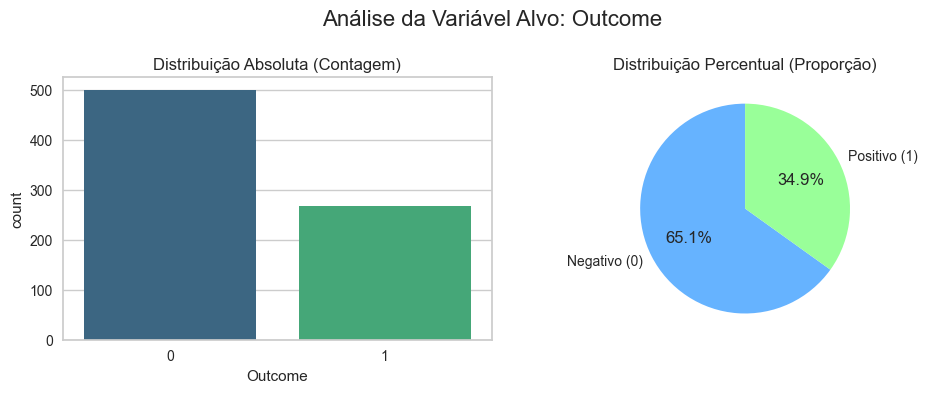

In [9]:
# Verificando a distribuição das classes
# 0 = teste negativo para diabetes
# 1 = teste positivo para diabetes

contagem = df['Outcome'].value_counts()
percentual = (df['Outcome'].value_counts(normalize=True)*100).round(2)
print(contagem) # contagem
print(percentual.astype(str)+'%') # percentual

# Configurando a contagem e a figura com 2 subplots (1 linha, 2 colunas)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Primeiro Gráfico (Barras) - Lado Esquerdo (ax[0])
sb.countplot(data=df, x='Outcome', hue='Outcome', palette='viridis', ax=ax[0], legend=False)
ax[0].set_title('Distribuição Absoluta (Contagem)')

# Segundo Gráfico (Pizza) - Lado Direito (ax[1])
ax[1].pie(contagem, labels=['Negativo (0)', 'Positivo (1)'], autopct='%1.1f%%',
        startangle=90, colors=['#66b3ff','#99ff99'])
ax[1].set_title('Distribuição Percentual (Proporção)')

# Ajustes de layout
plt.suptitle('Análise da Variável Alvo: Outcome', fontsize=16)
plt.tight_layout()
plt.show()

In [10]:
# Resumo estatísico descritivo das colunas do dataset
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [11]:
# Valor mínimo (min) com zeros
# Lista das colunas que queremos analisar
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Conta quantos valores são iguais a zero em cada uma
zeros_por_coluna = (df[cols] == 0).sum()

print("Quantidade de valores zero por coluna:")
print(zeros_por_coluna)

Quantidade de valores zero por coluna:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


### **Inferência sobre os dados - Distribuição e Análise estatística**

#### **Valores nulos ou duplicados**
Nosso dataset não possui registros com valores nulos e nem duplicados

#### **Distribuição das Classes (variável alvo Outcome)**
Nosso dataset está desbalanceado. Nosso gráfico de distribuição das classes mostra isso com clareza.
  - aproximadamente 34,9% das pacientes foram diagnosticadas com diabetes
  - quase o dobro de casos, ~65,1%, são negativos

#### **Análise Estatística**
O resumo estatísco nos mostra informções interessantes:
1. Aparentemente temos inconsistências nos dados
    - Várias colunas estão com valores zerados! O valor **min** está zerado para as variáveis *Glucose*, *BloodPressure*, *BMI*, *SkinThichness* e *Insulin*. Ninguém tem glicose, pressão, massa coporal, etc igual a zero...
    - Acreditamos que o dataset tenha sido preenchido com zeros para dados faltantes. Como temos poucos dados, vamos tratar isso no pré-processamento, preenchendo com a mediana ou a média, para não enviesar o aprendizado do modelo.
    - Vamos usar as técnicas descritas no Capítulo 7 do livro *Python para Análise de Dados* de McKinney (Edição 2018). Página 260, Substituindo valores.
2. Possíveis outliers e dispersões
    - *Pregnancies*: não que seja impossível, mas tem uma paciente no dataset com 17 gestações, de acordo com o valor **max**. É uma informação rara, mas pode afetar o nosso modelo.
    - *Insulin*: há indicativos de que os dados estejam muito espalhados. A média **mean** está em 79,79 μU/mL e o valor máximo **max** é 846 μU/mL! Além disso o desvio padrão **std** de 115,4 μU/mL é maior que a própria média, ou seja, existem pacientes com valores fora da curva. A quantidade de valores zerados, 374 registros no total, pode estar afetando essas métricas.
3. Características das pacientes
    - *BMI*: a média é de 31,99 e de acordo com os dados da OMS, já entra no range de obesidade. Olhando para o valor do 1º quartil **25%**, temos 75% da base com BMI acima de 27,3 o que indica sobrepeso, ou seja, este dataset possui um grupo de pacientes com alto risco metabólico.
    - *Age*: o dataset é composto por mulheres jovens, com algumas poucas idosas. Isso é demonstrado pelos valores da média, que é de 33 anos e mediana **50** com pacientes de 29 anos e o 3º quartil **75%** tem até 41 anos de idade. Algumas poucas idosas chegando até os 81 anos.
4. Outras observações
    - *Glucose*: a média de concentração de glicose da nossa base está em 120,89, considerada normal. Também é possível ver no 3º quartil que a concentração de glicose vai até 140,25, passando um pouco do nível normal. Poucas pacientes alcançam uma concentração até 199,0. O máximo é 199, pois pacientes com concentração de glicose acima de 199, já estaria com o diagnóstico de glicose segundo os autores do estudo que citamos anteriormente.
    - *BloodPressure*: a pressão arterial diastólica apresenta média 69,10 mmHg, considerada normal (dependendo da sistólica). Temos uma paciente com 122 mmHg que pode representar um caso de hipertensão. De acordo com o terceiro quartil, 25% da base está com a pressão acima de 80 mmHg.
    - *DiabetesPedigreeFunction*: os autores que criaram a função DPF para o estudo que citamos anteriormente não definem, no artigo, um range para determinar a influência para o diagnóstico da doença, desta forma não soubemos como avaliar essas estatíticas. O que podemos identificar foi que a fórmula apresentada no estudo tem Kx que envolve parentesco. Quando Kx = 0,500 o valor de DPF é alto, pois muitos parentes próximos tem histórico de diabetes. Em algumas buscas na internet, encontramos dados não oficiais que dizem, se o valor de DPF for igual ou maior a 2,5 a probabilidade da paciente ter diabetes é de aproximadamente 85%.

Vamos continuar nossa análise exploratória visualizando por meio de gráficos os outliers e as distribuições relevantes

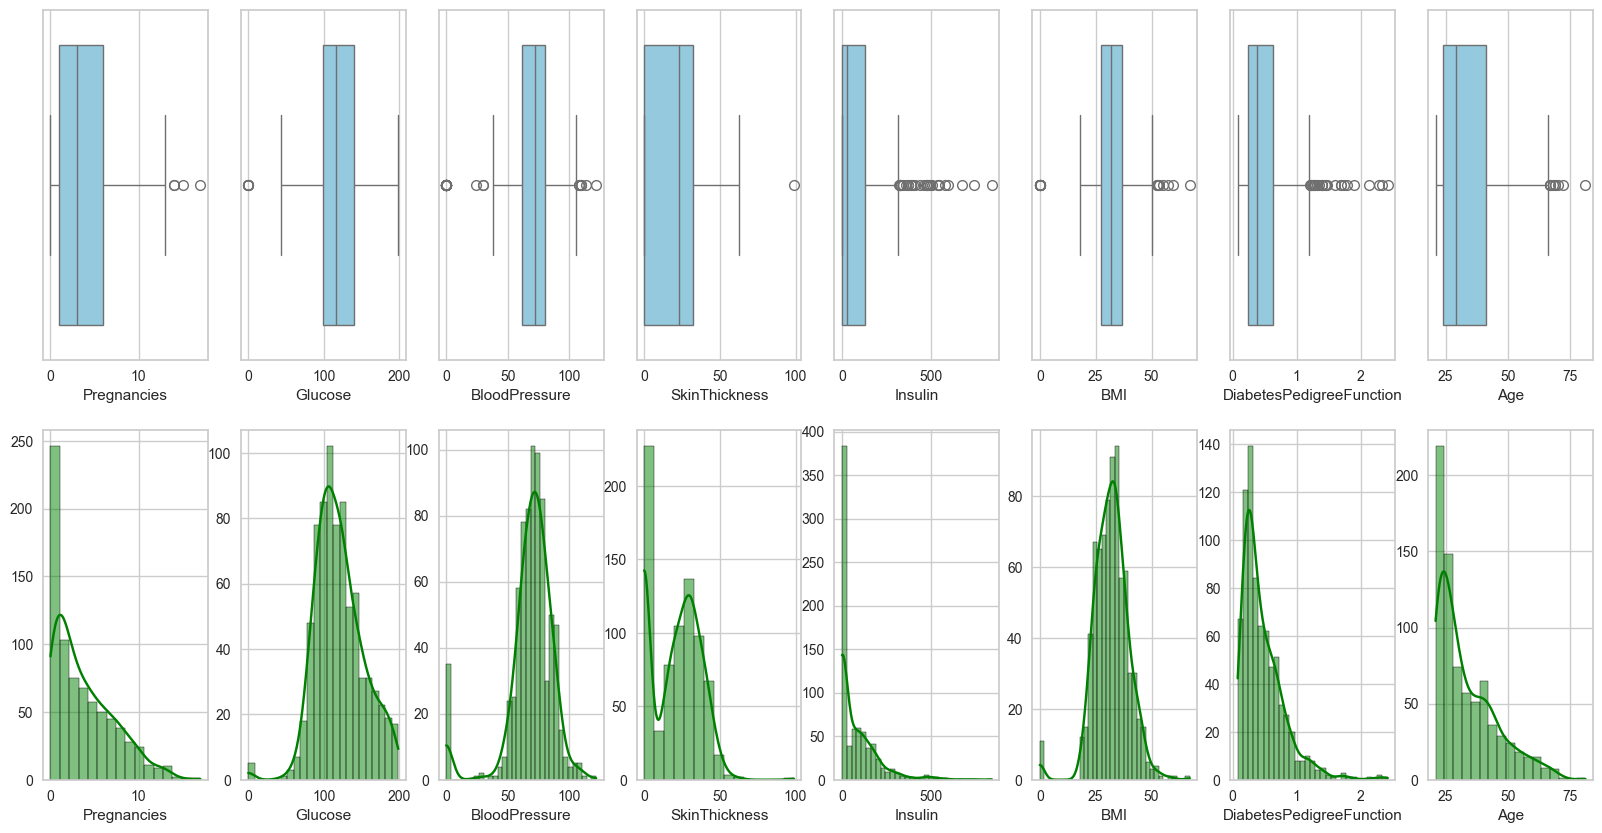

In [12]:
# MONTAR BOXPLOTS PARA VERIFICAR OUTLIERS E DISTRIBUIÇÕES
# Selecionando as colunas
cols = ['Pregnancies',	'Glucose',	'BloodPressure',	'SkinThickness',
        'Insulin',	'BMI',	'DiabetesPedigreeFunction',	'Age']
# Configurar uma grade de 2 linhas e 8 colunas
fig, ax = plt.subplots(2, 8, figsize=(20, 10))

# Plotar os 16 gráficos
for i, col in enumerate(cols):
    # Linha 1 boxplots
    sb.boxplot(x=df[col], ax=ax[0,i], color='skyblue')
    # Linha 2 histogramas
    sb.histplot(x=df[col], ax=ax[1,i], color='green', kde=True)
    ax[1, i].set_ylabel('')

### **Inferência sobre os dados - Analisando outliers e as distribuições**

Os gráficos nos ajudam na análise e confirmam visualmente nossa avaliação sobre algumas variáveis na análise descritiva

1. Confirmação dos valores zerados
    - *Glucose*, *BloodPressure* e *BMI*: é possível notar um pequeno pico isolado a esquerda de cada gráfico, esxatamente no valor 0 (zero). O restante da distribuição é normal o que comprova que esses seros são dados faltantes que foram preenchidos incorretamente ou não foram obtidos.
    - *SkinThickness* e *Insulin*: o count que fizemos anteriormente (Célula [24], quantidade de valores zerados por coluna), nos trouxe para essa duas variáveis os valores absurdos de 227 e 334 respectvamente. O que signfica que para quase a metade das pacientes (no caso da insulina) estes dados não foram coletados.
2. Outliers (boxplot)
    - *Pregnancies*: notamos pontos acima de 13 gestações, o que confirma que o valor 17 é estatisticamente raro.
    - *Insulin*: caso mais extremo, mas os valores com zero estão impactando nesse gráfico. A caixa azul é pequena e está espremida próximo ao zero. No entanto temos uma long linha de ponto que chega quase a 900.
    - *DiabetesPedigreeFunction*: da mesma forma que as anteriores apresenta muitos outliers.
    - *BMI* e *Age*: também apresentam outliers, em ambos variáveis há um ponto bem afastado à direita do gráfico. Estes são os pontos que representam o **max** 67,1 e 81 respectivamente.
3. Distribuições (histograma)
    - *Glucose*, *BloodPressure* e *BMI*: apresentam uma distribuição normal, um formato de sino quase perfeito, se desconsiderarmos os zeros. Isso é ótimo para a maioria dos modelos de ML.
    - *Pregnancies*, *DiabetesPedigreeFunction* e *Age*: apresentam uma distribuição assimétrica. Concentrando a maioria das pacientes em valores baixos, com pouca representação em valores altos. Em *Age* vemos que a maioria estána faixa dos 20 a 30 anos, o que confirma nossa análise sobre uma base com mulheres jovens.

Os gráficos confirmam a necessidade de tratamento e limpeza dos dados, os zeros precisam ser tratados antes de prosseguir. Os outliers também precisam ser tratados, vamos usar a técnica de escalonamento.

**Com base no que foi analisado até agora, podemos começar formulando algumas perguntas**:

> *A quantidade de gestações (Pregnancies) pode ser um risco de diabetes?*

> *Conforme descrito no início da análise, níveis de glicose (Glucose) entre 140 e 199 indicam um pré disposição à diabetes. Nosso dataset comprova esse indicador?*

> *A pressão arterial (BloodPressure) pode ser um bom preditor para nosso modelo?*

> *Pessoas com diabetes podem ter a espessura da pele (SkinThickness) diferente das que não tem o diagnóstico da doença?*

> *Insulina (Insulin), o hormônio do corpo que regula o metabolismo da glicose. Níveis baixos podem indicar diabetes, mas a análise e interpretação depende do tipo de diabetes. Será que conseguimos enxergar o cenário clássico, onde o nível de insulina baixa x glicose alta pode indicar presença da doença?*

> *Pacientes acima são propensas à diabetes? A massa corporal (BMI) pode ser bom preditor?*

> *A função de histórico familiar (DiabetesPedigreeFunction), criada pelos autores do estudo que citamos, pode ser considerada um indicador útil?*

> *E a idade (Age)? Pode influenciar de alguma forma?*

Para responder a estas perguntas, vamos fazer as correlações entre estas variáveis e também plotar gráficos boxplot e violino.

**NOTA**: vamos fazer a análise sem o tratamento dos valores zerados para ver como ficam nossas correlações.


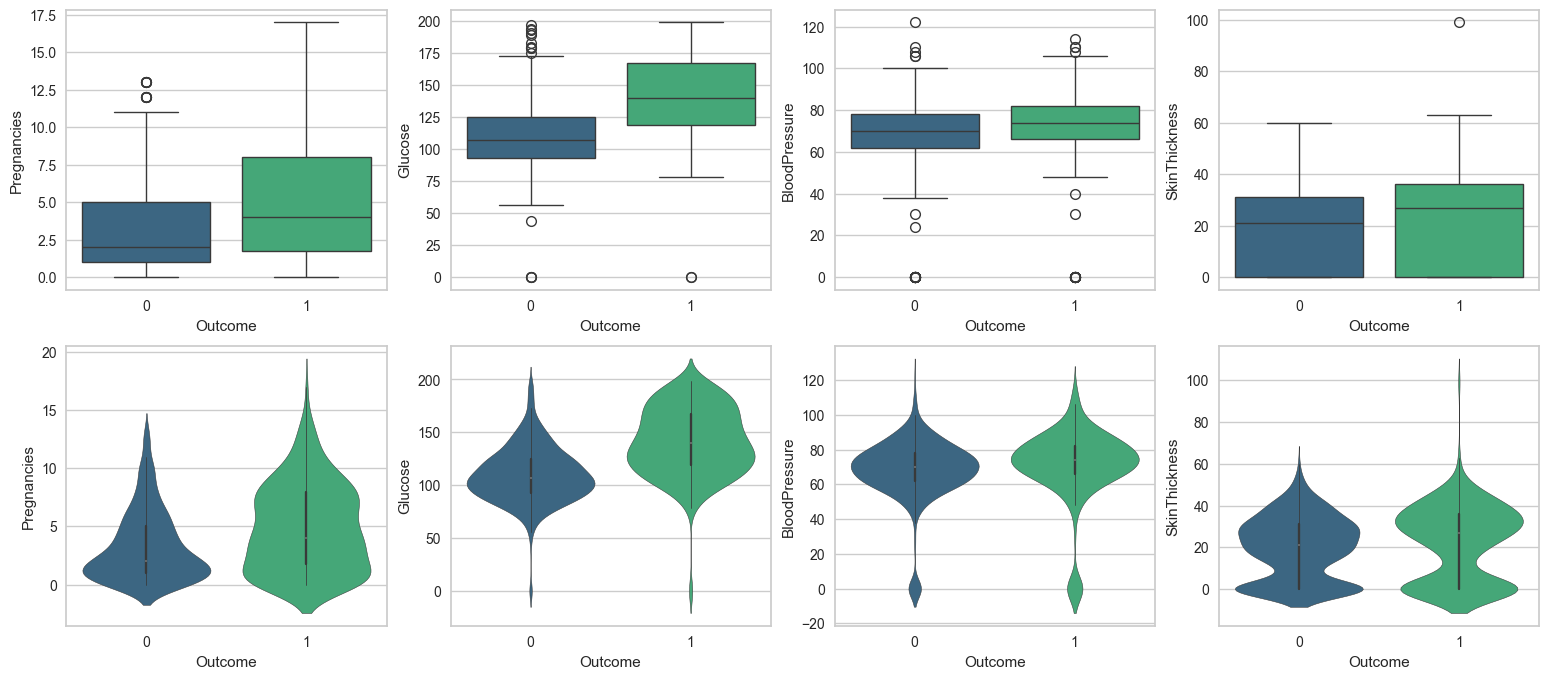

In [13]:
# PLOTAR BOXPLOT E VIOLINOS - PRIMEIRAS 4 VARIÁVEIS
# Analisar a relação entre as 4 primeiras variáveis independentes e variável alvo

# Selecionando as colunas
cols = ['Pregnancies',	'Glucose',	'BloodPressure',	'SkinThickness']

# Configurar uma grade de 2 linhas e 4 colunas
fig, ax = plt.subplots(2, 4, figsize=(19, 8))

# Plotar os 8 gráficos
for i, col in enumerate(cols):
    # Linha 1 boxplots
    sb.boxplot(data=df, x='Outcome', y=col, ax=ax[0,i], palette='viridis')
    # Linha 2 violino
    sb.violinplot(data=df, x='Outcome', y=col, ax=ax[1,i], palette='viridis')

### **Inferência sobre os dados - Analisando as Distribuiçoes - Base não tratada**
#### Variáveis independentes: *Pregnancies,	Glucose,	BloodPressure e	SkinThickness*

Analisando os gráficos podemos responder nossas primeiras 4 perguntas

1. **A quantidade de gestações (Pregnancies) pode ser um risco de diabetes?**

    Sim, esta variável pode ser uma boa preditora para nosso modelo.

    - Existe uma tendência aparente, as pacientes com diabetes (cor verde) tendem a ter um número superior de gestações se comparado ao grupo sem diabetes
    - Aqui os outlieres são evidenciados na parte superior do grupo sem diabetes, mulheres com muitas gestações e que não desenvolveram a doença
    
2. **Conforme descrito no início da análise, níveis de glicose (Glucose) entre 140 e 199 indicam um pré disposição à diabetes. Nosso dataset comprova esse indicador?**

    Sim! Os gráficos comprovam que esse indicador é um ótimo preditor

    - A caixa que representa as pacientes diabéticas está muito acima da caixa das não diabéticas. A mediana de quem tem diabetes está próxima de 150 o que indica pré disposição. A mediana de quem não tem diabetes está em torno de 110.
    - Outliers são vistos em ambos os grupos, são os pontos com valores zerados. A maior frequencia é no grupo que não tem diabetes.

3. **A pressão arterial (BloodPressure) pode ser um bom preditor para nosso modelo?**

    Não parece ser um bom preditor.

    - As medianas e as caixas do boxplot estão muito próximas uma da outra
    - Os gráficos de violino também são similares para ambos os grupos. A pressão da maioria das pacientes está na faixa considerada normal.

4. **Pessoas com diabetes podem ter a espessura da pele (SkinThickness) diferente das que não tem o diagnóstico da doença?**

    Aparentemente não. Essa variável não pode ser considerada um bom indicador.

    - Da mesma forma que a pressão sanguínea, os gráficos estão muito parecidos, as caixas se sobrepõe no boxplot, a mediana é um pouco superior, mas não que seja relevante.
    - As bases no gráfico do violiono são muito largas próximas ao zero. Indicando nosso problema com os dados zerados. Para essa variável, temos 227 registros com zero.

Respondemos as quatro primeiras perguntas, vamos seguir plotando restante das nossas variáveis independentes.


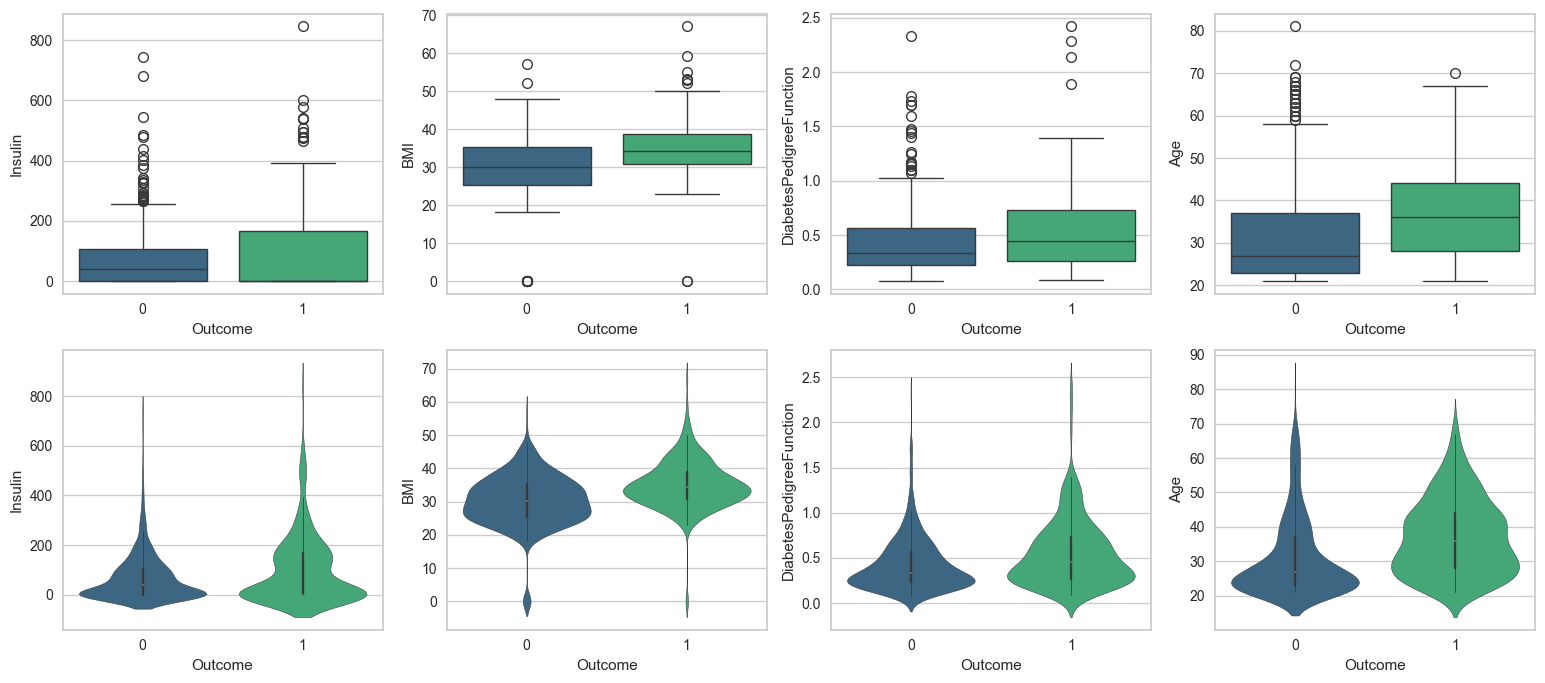

In [14]:
# PLOTAR BOXPLOT E VIOLINOS - 4 VARIÁVEIS RESTANTES
# Analisar a relação entre as 4 variáveis independentes restantes e variável alvo

# Selecionando as colunas
cols = ['Insulin',	'BMI',	'DiabetesPedigreeFunction',	'Age']

# Configurar uma grade de 2 linhas e 4 colunas
fig, ax = plt.subplots(2, 4, figsize=(19, 8))

#sb.boxplot(x='Outcome',y='BMI',data=df,ax=ax[0], palette='viridis')
#sb.violinplot(x='Outcome',y='BMI',data=df,ax=ax[1], palette='viridis')
# Plotar os 8 gráficos
for i, col in enumerate(cols):
    # Linha 1 boxplots
    sb.boxplot(data=df, x='Outcome', y=col, ax=ax[0,i], palette='viridis')
    # Linha 2 violino
    sb.violinplot(data=df, x='Outcome', y=col, ax=ax[1,i], palette='viridis')

### **Inferência sobre os dados - Analisando as Distribuiçoes - Base não tratada**
#### Variáveis independentes: *Insulin,	BMI,	DiabetesPedigreeFunction,	Age*

Analisando os gráficos podemos responder nossas primeiras últimas perguntas

5. **Insulina (Insulin), o hormônio do corpo que regula o metabolismo da glicose. Níveis baixos podem indicar diabetes, mas a análise e interpretação depende do tipo de diabetes. Será que conseguimos enxergar o cenário clássico, onde o nível de insulina baixa x glicose alta pode indicar presença da doença?**

    Do jeito que a base está, com muitos valores zerados. Essa variável não tem tanta relevência

    - A maior concentração de outliers está aqui, são 374 registros com valores zerados.
    - O gráfico de violino tem uma concentração muito grande perto do zereo em ambos os grupos. Também é possível ver que existe uma paciente com o nível de insulina bantendo quase em 900.
    
6. **Pacientes acima são propensas à diabetes? A massa corporal (BMI) pode ser bom preditor?**

    Bom preditor

    - A separação entre as caixas é mais relevante. As mediana para o grupo com diabetes está acima de 34, já o grupo não diabético está próxima de 30
    - O primeiro quartil do grupo diabético é quase igual a mediana do grupo sem diabetes, ou seja, um indice elevado é um indicador considerável de risco

7. **A função de histórico familiar (DiabetesPedigreeFunction), criada pelos autores do estudo que citamos, pode ser considerada um indicador útil?**

    Não parece ser um preditor bom

    - Pacientes com scores maiores aparecem no grupo com diabetes
    - Existem diversas pacientes no grupo de não diabetes com scores acima de 1.5, no entanto, não desenvolveram a doença.    

8. **E a idade (Age)? Pode influenciar de alguma forma?**

    Bom preditor

    - As pacientes com diabetes tem a tendência de serem mais velhas. A mediana da idade está próxima dos 36 anos. O grupo sem a doença está com a mediana em 27 anos.
    - O gráfico de violino demontra bem essa divisão. No grupo das saudáveis há uma concentração na parte inferior do violino, enquanto no grupo das diabéticas a distribuição é mais espalhada entre os 30 e 50 anos.
    - Dado curioso. A paciente com 81 anos, está no grupo saudável.
    
Com base nas nossas respostas

| Variável | Bom Preditor? | Observação |
| :--- | :----: | :--- |
| Pregnancies | Sim |  |
| Glucose | Sim |  |
| BloodPressure | Não |  |
| SkinThickness | Não | A base precisa ser tratada, muitos valores zerados |
| Insulin | Não | A base precisa ser tratada, muitos valores zerados |
| BMI | Sim |  |
| DiabetesPedigreeFunction | Não |  |
| Age | Sim |  |

**NOTA**: Vamos fazer o tratamento dos dados e fazer uma nova análise correlação e distribuição. Após isso, vamos montar a matriz de correlação para confirmar se apontamos os preditores corretamente.


# 2. PRÉ-PROCESSAMENTO DOS DADOS

### **Tratando as inconsistências**

#### **Substituir os valores zerados**
  - Usar a função *replace()* com a mediana, função *median()* e com a média função *mean()* para substituir os valores zerados das variaveis *Glucose*,	*BloodPressure*,	*SkinThickness*,	*Insulin* e	*BMI*
  - Vamos criar dois dataframes temporários para verificar qual substituição foi a melhor.

In [15]:
# TRATAR AS INCONSSISTÊNCIAS - VALIDAR PREENCHIMETO COM MEDIANA E MÉDIA

# Variáveis a serem tratadas
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

# Dataframes temporários
df_mediana = df.copy()
df_media = df.copy()

# Substitui os valores zerados pela média
for i in cols:
   df_mediana[i].replace(0, df[i].median(), inplace=True)
   df_media[i].replace(0, df[i].mean(), inplace=True)

In [16]:
# Análise descritiva do dataframe preenchido com a mediana
df_mediana.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [17]:
# Análise descritiva do dataframe preenchido com a media
df_media.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.681605,72.254807,26.606479,118.660163,32.450805,0.471876,33.240885,0.348958
std,3.369578,30.436016,12.115932,9.631241,93.080358,6.875374,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,20.536458,79.799479,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,79.799479,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### **Análise Descritiva após substituição dos valores zerados**

  - O preenchimento com a média foi melhor pois o desvio padrão da variável *Insulin* ficou abaixo da média, com 93,08. O preenchimento com a mediana manteve o desvio padrão da variável acima da média, com um valor de 105,54.

Vamos aplicar agora a substituição no Dataframe original.

In [18]:
# TRATAR AS INCONSSISTÊNCIAS - SUBSTITUIR OS VALORES ZERADOS PELA MÉDIA DE CADA VARIÁVEL
# Variáveis a serem tratadas
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

# Conta quantos valores são iguais a zero em cada uma
zeros_por_coluna = (df[cols] == 0).sum()

print("Quantidade de valores zero por coluna antes do tratamento:")
print(zeros_por_coluna)


# Substitui os valores zerados pela média
for i in cols:
   df[i].replace(0, df[i].mean(), inplace=True)

# Conta quantos valores são iguais a zero em cada uma
zeros_por_coluna = (df[cols] == 0).sum()

print("\nQuantidade de valores zero por coluna depois do tratamento:")
print(zeros_por_coluna)

Quantidade de valores zero por coluna antes do tratamento:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Quantidade de valores zero por coluna depois do tratamento:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


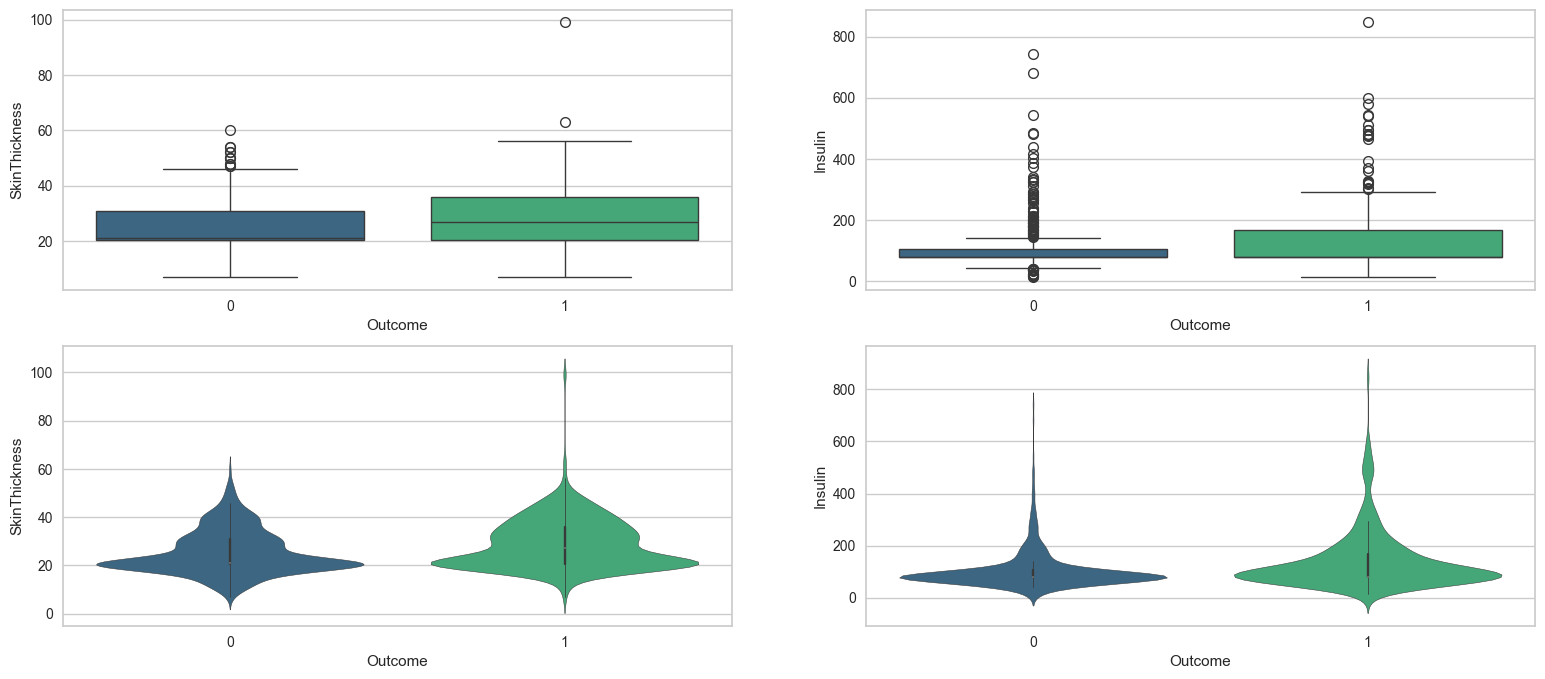

In [19]:
# PLOTAR BOXPLOT E VIOLINOS - VARIÁVEIS SkinThickness e Insulin
# Após o tratamento da dos valores zerados. Analisar novamente a distribuição destas
# variáveis que tinham o maior volume de valores zerados

# Selecionando as colunas
cols = ['SkinThickness', 'Insulin']

# Configurar uma grade de 2 linhas e 2 colunas
fig, ax = plt.subplots(2, 2, figsize=(19, 8))

# Plotar os 4 gráficos
for i, col in enumerate(cols):
    # Linha 1 boxplots
    sb.boxplot(data=df, x='Outcome', y=col, ax=ax[0,i], palette='viridis')
    # Linha 2 violino
    sb.violinplot(data=df, x='Outcome', y=col, ax=ax[1,i], palette='viridis')

### **Inferência sobre os dados - Analisando as Distribuiçoes de SkinThickness e Insulin - Base tratada**

  - Como *SkinThickness* e *Insulin* tinham o maior volume de valores zerados, 227 e 374 respectivamente, plotamos, novamente, os gráficos apenas para estas varíaveis. Fica nítido, em compartação com os gráficos anteriores, que tanto as caixas dos boxplots quanto os violinos, não estão mais encotados na linha do zero na parte inferior dos gráficos, demonstrando que nosso preenchimento pela média ajutou nossos dados

Vamos aplicar agora um Pairplot e a Matriz de Correlação para verificarmos a influência que terão sobre nosso modelo.

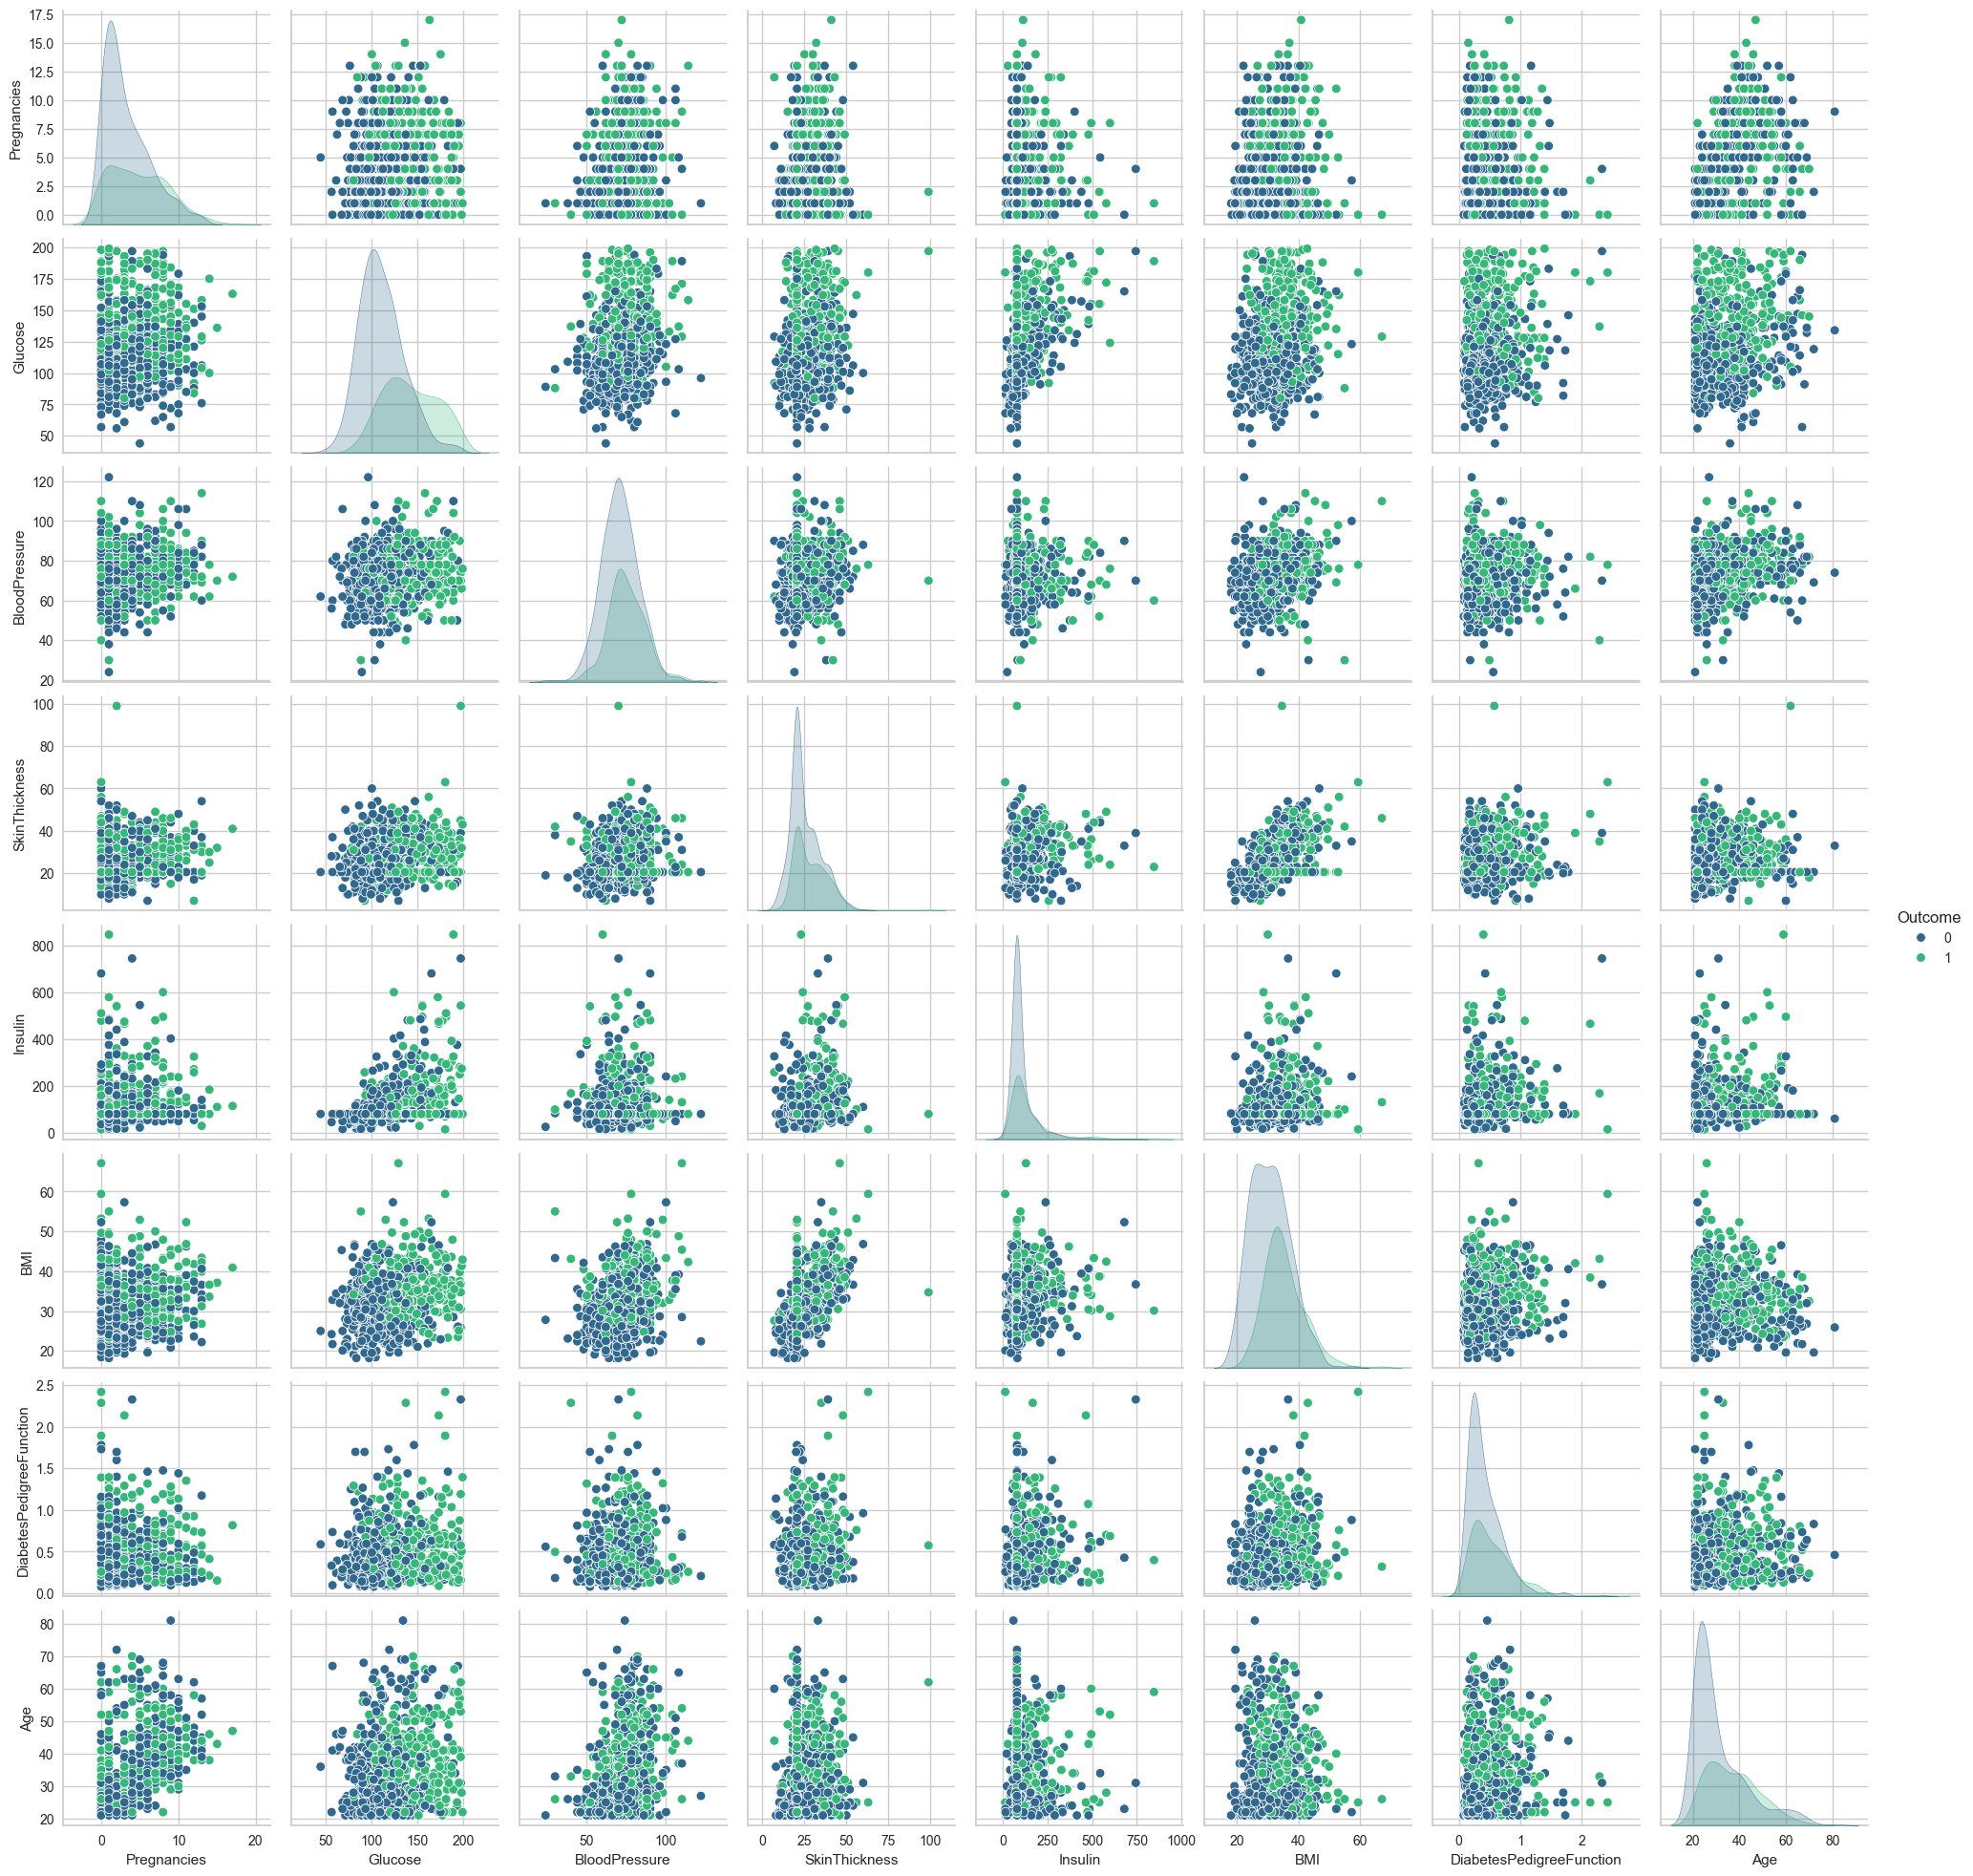

In [20]:
# PAIRPLOT PARA ANÁLISE DE CORRELAÇÃO VISUAL E DISTRIBUIÇÃO
cols = ['Pregnancies',	'Glucose',	'BloodPressure',	'SkinThickness',
        'Insulin',	'BMI',	'DiabetesPedigreeFunction',	'Age']
sb.pairplot(df,vars=cols, hue='Outcome', plot_kws={'alpha':1}, palette='viridis')

<Axes: >

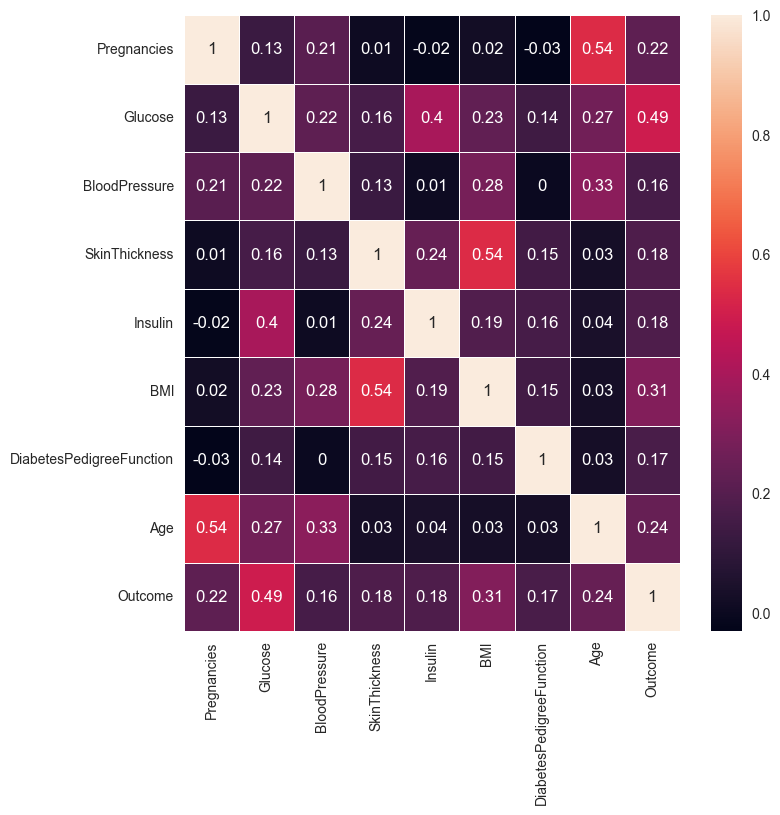

In [21]:
# MATRIZ DE CORRELAÇÃO
correlation_matrix = df.corr(numeric_only=True).round(2)
# Plotar a matriz de correlação com um heatmap
fig, ax = plt.subplots(figsize=(8,8))
sb.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax)

### **CONCLUSÃO DA ANÁLISE - Inferência sobre os dados - Analisando o Pairplot e a Matriz de Correlação**

#### **PAIRPLOT**
1. **Outliers ficaram mais evidentes**
    Diferente dos bloxplots, o pairplot nos permite ter noção da disperção dos outliers. Quase todas as relações possuem pontos dispersos nos planos dos gráficos.

2. **Distribuição diagonal**
    Nos histogramas, antes do tratamento dos valores zerados, víamos que somente *Glucose*, *BloodPressure* e *BMI* apresentavam uma distribuição próxima ao normal. Após o tratamento, podemos notar que as algumas outras variáveis também ganharam a forma aproximada de um sino.

3. **Agrupamento**
    No cruzamento da variável *Glucose* é possível verificar que a concentração de diabéticos (cor verde) fica concentrada no topo dos gráficos que cruzam com esta variável.

#### **MATRIZ DE CORRELAÇÃO**
1. **Variáveis com maior impacto no Outcome
    A última linha (ou coluna) mostra a correlação direta com a variável alvo. As variáveis que mais se destacam são**:

    *Glucose*, com 0.49. É a correlação mais forte. Isso confirma o que vimos nos gráficos de violino: a glicose é o principal separador entre diabéticos e não diabéticos.

    *BMI*, com 0.31. Tem uma correlação moderada e positiva, indicando que o aumento do IMC está ligado ao risco de diabetes.

    *Age*, com 0.24 e *Pregnancies*, 0.22. Ambas mostram uma influência relevante, sugerindo que o fator tempo e o histórico gestacional contribuem para o modelo.

2. **Identificação de Multicolinearidade**
  
    É posssivel observar correlações altas entre as variáveis independentes (geralmente acima de 0.7 ou 0.8). Na matriz, notamos alguns pares interessantes, mas nenhum que exija a exclusão imediata:

    *Age* x *Pregnancies*, com 0.54. Existe uma correlação moderada natural. Quanto mais velha a paciente, mais tempo ela teve para ter mais gestações.

    *SkinThickness* x *BMI*, 0.54. Também esperado, já que a espessura da dobra cutânea é um indicador de gordura corporal, assim como o IMC.

    *Glucose* x *Insulin* (0.40): Reflete a relação onde níveis altos de açúcar no sangue costumam vir acompanhados de níveis altos de insulina em casos de resistência.

Concluindo, vamos manter todas as variáveis para o treinamento do modelo. Mesmo existindo variáveis com baixa correlação como *BloodPressure* e *DiabetesPedigreeFunction*, podemos extrair informações únicas que combinadas com outras podem fazer o modelo entender melhor alguns casos.

# 3. TREINAMENTO DOS MODELOS

ATENÇÃO SERÁ NECESSÁRIO ESCALONAR OS DADOS O dataset possui variáveis com escalas diferentes (exemplo, *Insulin* pode chegar até 800, enquanto DiabetesPedigreeFunction está entre 0,07 e 2,4), será necessário escaloná-los usando StandardScaler devido a grande quantidade de outliers.

# Serão treinados e avaliados 4 modelos
- Regressão Logística
- KNN
- Árvore de Decisão
- Floresta Aleatória

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import validation_curve
from sklearn.model_selection import GridSearchCV

# Serão avaliados 4 modelos de classificação
from sklearn.linear_model import LogisticRegression # Regressão Logística
from sklearn.neighbors import KNeighborsClassifier # KNN
from sklearn.tree import DecisionTreeClassifier # Árvore de Decisão
from sklearn.ensemble import RandomForestClassifier # Floresta Aleatória

In [23]:
# PREPARAR DATASETS PARA O TREINAMENTO

# Separando as variáveis independentes (X) e a variável target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Separando a base em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f'O dataset de treino possui {X_train.shape[0]} linhas e {X_train.shape[1]} variáveis')
print(f'O dataset de teste possui {X_test.shape[0]} linhas e {X_test.shape[1]} variáveis')

# Escalonando os datasets de treino e teste
scaler = StandardScaler()

# Ajustar o scaler e transformar os dados de treino
X_train_escalonado = scaler.fit_transform(X_train)

# Transformar os dados de teste usando o scaler ajustado nos dados de treino
X_test_escalonado = scaler.transform(X_test)

O dataset de treino possui 614 linhas e 8 variáveis
O dataset de teste possui 154 linhas e 8 variáveis


In [24]:
# Validar a proporção original da variável target entre treino e teste
print("\nComparativo para validar a proporção da variável target:")
total = df['Outcome'].value_counts(normalize=True) * 100
treino = y_train.value_counts(normalize=True) * 100
teste = y_test.value_counts(normalize=True) * 100

tabela_comparativa = pd.DataFrame({
    'Dataset Original (%)': total,
    'Treino (%)': treino,
    'Teste (%)': teste
}).round(2)

tabela_comparativa.index = ['Não Diabético (0)', 'Diabético (1)']
print(tabela_comparativa)


Comparativo para validar a proporção da variável target:
                   Dataset Original (%)  Treino (%)  Teste (%)
Não Diabético (0)                  65.1       65.15      64.94
Diabético (1)                      34.9       34.85      35.06


### **PRIMEIRO MODELO: Regressão Logística (com dados escalonados)**

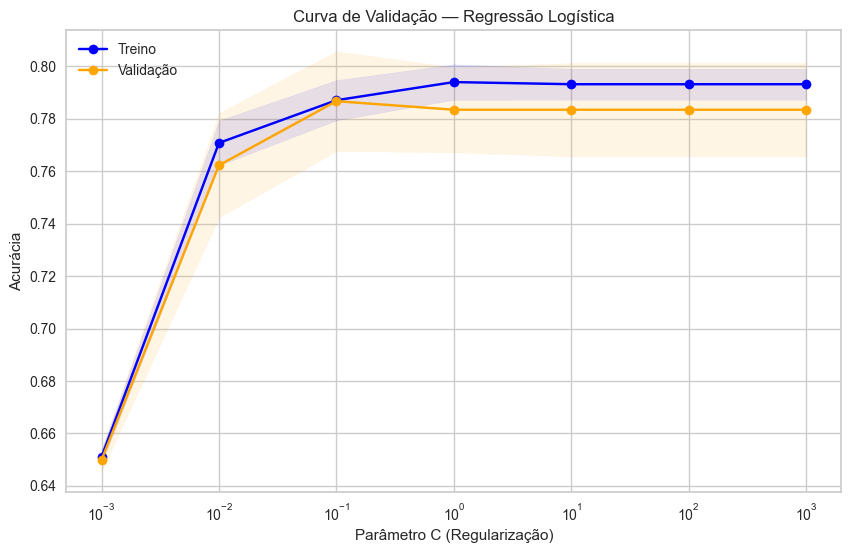

In [25]:
# REGRESSÃO LOGÍSTICA - TESTAR PARAMETROS E VALIDAR A CURVA DE VALIDAÇÃO

# Para Regressão Linear o parametro mais importante é o C

# Definir o intervalo de busca para C (escala logarítmica)
param_range = np.logspace(-3, 3, 7) # de 0.001 até 1000

# Calcular a curva de validação
train_scores, test_scores = validation_curve(
    LogisticRegression(max_iter=1000),
    X_train_escalonado, y_train,
    param_name="C",
    param_range=param_range,
    cv=5,               # Validação cruzada em 5 dobras
    scoring="accuracy", # pode usar "f1" ou "recall" também
    n_jobs=-1
)

# Calcular médias e desvios padrão
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plotar o gráfico
plt.figure(figsize=(10, 6))
plt.semilogx(param_range, train_mean, label="Treino", color="blue", marker="o")
plt.semilogx(param_range, test_mean, label="Validação", color="orange", marker="o")

plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.1, color="orange")

plt.title("Curva de Validação — Regressão Logística")
plt.xlabel("Parâmetro C (Regularização)")
plt.ylabel("Acurácia")
plt.legend(loc="best")
plt.grid(True)
plt.show()

### **Analisando a Curva de Validação**

- As linhas de treino e validação estão sobrepostas em C=10¹, que é 0,1, chegando quase a 0,79 de acurácia. Isso indica que nosso modelo pode performar tanto em dados novos quanto os de treino.

- A variância, representada pela área laranja sombreada está bem reduzida, o modelo é confiável e pode ser menos sensível a separação dos dados. Aqui, os dados escalonados ajudam na regressão logística.

In [26]:
# REGRESSÃO LOGÍSTICA - TREINO DO MODELO COM C = 0.1

map = {0: 'Não', 1: 'Sim'}

# Cria o modelo
modelo_regressao_logistica = LogisticRegression(C=0.1, random_state=42)
modelo_regressao_logistica.fit(X_train_escalonado, y_train)

# Faz uma predição com o primeiro registro do nosso X escalonado
primeiro_registro = X_test_escalonado[[0]]
target_real = y_test.iloc[0] # Primeiro registro do target
print(f'No registro real a paciente tem diabetes?\n {map[target_real]}\n')

# Predição
predicao = modelo_regressao_logistica.predict(primeiro_registro)[0]

# Valida se o modelo acertou comparando a predição com o dado real
resultado = map[target_real] == map[predicao]

# Imprime os resultados
print(f'O modelo previu a paciente com diabetes?\n {map[predicao]}\n')
print(f'O modelo acertou?\n {map[resultado]}\n')
print(f'Proba:\nChance de não ter Diabetes {modelo_regressao_logistica.predict_proba(primeiro_registro)[0][0].round(2)}\nChance de ter Diabetes {modelo_regressao_logistica.predict_proba(primeiro_registro)[0][1].round(2)}')
print(f'Score: {modelo_regressao_logistica.score(X_test_escalonado, y_test)}')

No registro real a paciente tem diabetes?
 Não

O modelo previu a paciente com diabetes?
 Sim

O modelo acertou?
 Não

Proba:
Chance de não ter Diabetes 0.43
Chance de ter Diabetes 0.57
Score: 0.7077922077922078


### **Interpretando o resultado do treino**

In [27]:
#PLOTAR GRÁFICO DE FORÇA

# Inicializar Javascript para as visualizações do SHAP
shap.initjs()

s = shap.LinearExplainer(modelo_regressao_logistica, X_train_escalonado, C=1.0, randon_state=42)
shap_vals = s.shap_values(X_test_escalonado)

amostra = 0 # Testando a primeira paciente do dataset de teste
target_idx = 1 # Tem diabetes

# Plota o gráfico.
shap.force_plot(s.expected_value, shap_vals[amostra, :], X_test_escalonado[amostra,:], feature_names=X.columns)

In [28]:
# Convertendo o valor final log-odds para probabilidade
logit = 0.30
probabilidade = 1 / (1 + np.exp(-logit))
print(f"A probabilidade é: {probabilidade:.4f}")

A probabilidade é: 0.5744


Na predição de teste com apenas uma amostra, o modelo errou, nos lançou um Falso Positivo, dizendo que a paciente tem diabetes quando na verdade ela não tem. Em se tratando de saúde, esse cenário não é tão ruim, é preferível um alerta falso positivo, a um falso negativo, informando que a paciente não tem diabetes quando na verdade ela tem.

O gráfico de força ajuda entender como o modelo tomou a decisão para essa única paciente baseando-se na contribuição de cada variável independente.

Como os dados estão escalonados e estão na escala de log-odds (logarimo das chances), o *base value* de -0,8844 representa a probabilidade média da paciente ter diabetes. O valor da glicose é de 1.244 acima de 1 desvio padrão este valor alto está empurrando o modelo para diagnosticar a paciente positivamente. Pregnancies e Age também são consideradas como um fator de risco para esse modelo.

Quando convertemos o valor 0,30 para probabilidade, chegamos a 57% de probabilidade conforme podemos ver no proba.

In [29]:
# Interpretando o Intercepto e os coeficientes (função extraída do livro de Harrisson)
def inv_logit(p):
  return np.exp(p) / (1 + np.exp(p))

print(f'O intercepto é: {modelo_regressao_logistica.intercept_}')
print(f'A proporção é: {inv_logit(modelo_regressao_logistica.intercept_)}')

O intercepto é: [-0.83656599]
A proporção é: [0.30225852]


Nosso intercepto é de ~-0,84. O negativo representa que a probabilidade de uma paciente ter Diabetes é menor que 50% para a ausência de fatores de risco. Vamos analisar os coeficientes para verificar a importância de cada um na decisão do modelo.

A proporção, é um valor bem próximo ao que vimos no gráfico de força, confirmando a consistência do modelo.

In [30]:
# Inspecionando os coeficientes
modelo_regressao_logistica.coef_

# Cria a lista com as variáveis e lista por ordem decrescente de importância
cols = X.columns
for col, val in sorted(zip(cols, modelo_regressao_logistica.coef_[0]), key=lambda x: x[1], reverse=True):
  print(f'{col:10}{val:10.3f} {inv_logit(val):10.3f}')

Glucose        1.037      0.738
BMI            0.600      0.646
Pregnancies     0.324      0.580
DiabetesPedigreeFunction     0.213      0.553
Age            0.161      0.540
SkinThickness     0.039      0.510
BloodPressure    -0.015      0.496
Insulin       -0.042      0.490


Glucose é a variável com maior influência positiva no diagnóstico, 1,203. Em contrapartida, Insulin tem peso negativo -0,105.

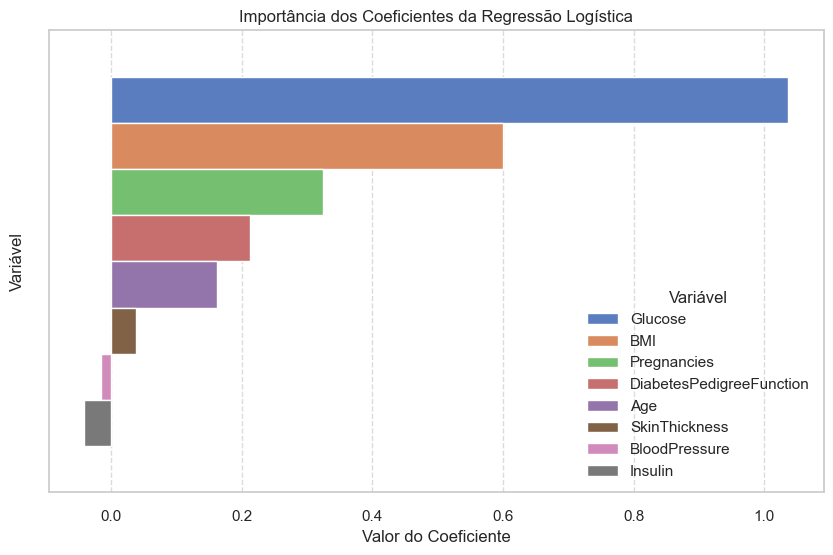

In [31]:
# PLOTAR UM BARPLOT PARA INSPECIONAR OS COEFICIENTES VISUALMENTE

# Cria um DataFrame para os coeficientes
df_coef = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': modelo_regressao_logistica.coef_[0]
})

# Ordenar os coeficientes para melhor visualização
df_coef = df_coef.sort_values(by='Coeficiente', ascending=False)

# Plotar os coeficientes
sb.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(10, 6))
sb.barplot(data=df_coef, x='Coeficiente', hue='Variável')
plt.title('Importância dos Coeficientes da Regressão Logística')
plt.xlabel('Valor do Coeficiente')
plt.ylabel('Variável')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

As barras para a direita do zero indicam que conforme o valor das variáveis aumenta maior a probabilidade para um diagnótico positivo de diabetes. As variáveis *Glucose*, *BMI* e *Pregnancies* estão no top 3 e validam nossos gráficos de matriz de correlação e os gráficos de violino.

As barras a esquerda do zero, indicam a relação inversa ou irrelevância para a decisão do nosso modelo.

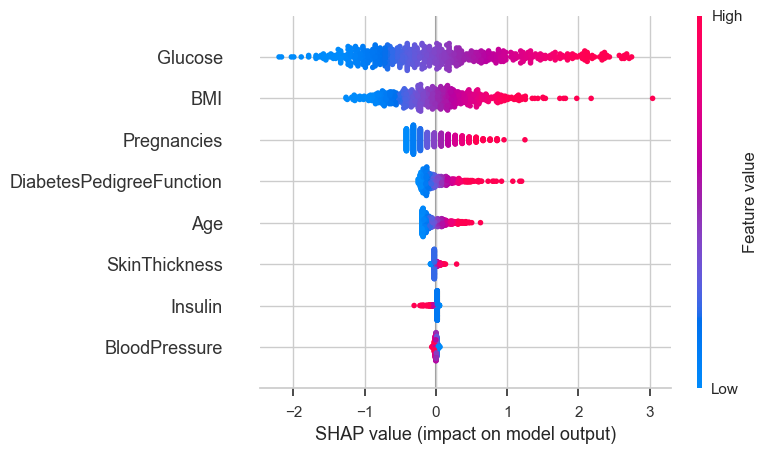

In [32]:
# PLOTAR GRÁFICO SUMÁRIO DAS VARIÁVEIS

# Cria o explainer
explainer = shap.LinearExplainer(modelo_regressao_logistica, X_train_escalonado, feature_perturbation="interventional")

# Calcula os valores SHAP para o conjunto de teste
shap_values = explainer.shap_values(X_train_escalonado)

# Gera o Summary Plot
shap.summary_plot(shap_values, X_train_escalonado, feature_names=X.columns)

O gráfico sintetizado acima, mostram novamente a mesma ordem de importância das variáveis. Ele explica e confirma visualmente os coeficientes que vimos anteriormente.

Glucose e BMI no topo, os pontos vermelhos que representas cos valores mais altos estão deslocados para a direita, confirmando aquele coeficiente positivo de 1,037 para glicose.

Sobre os sinais invertidos, BloodPressure e Insulin, existe uma pequena concentração de pontos vermelhos no lado esquerdo azul, são os coeficientes negativos atribuidos a elas pelo modelo -0.015 e -0.042 respectivamente.

Por fim, podemos explicar o que ocorreu com nosso teste do primeiro registro da base, onde o modelo errou. Para Glucose, tem uma grande concentração de pontos roxos na linha do zero, a paciente do teste tinha glicose de 1,244 (escalonado), esse valor no gráfico, está na área onde o modelo começa a classificar como diabético, como o IMC era baixo -0,7395, o modelo tentou "empurrar" de volta para zero, mas não foi o suficiente para sair da zona de risco.

### **SEGUNDO MODELO: KNN**

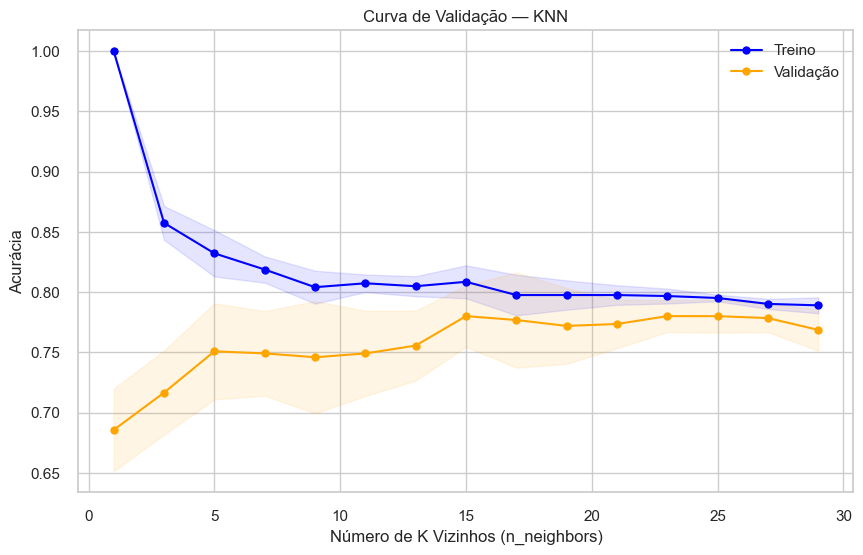

In [33]:
# KNN - TESTAR PARAMETROS E VALIDAR A CURVA DE VALIDAÇÃO

# Para KNN o parametro mais importante é o n_neighbors

# Número de vizinhos (valores ímpares para evitar empates)
# Inicia em 1 vai até 31, sem incluí-lo
# Pega somente valores impares, ou seja, vai de 1 até 29 K vizinhos
param_range = np.arange(1, 31, 2)

# Calcular a curva de validação
train_scores, test_scores = validation_curve(
    KNeighborsClassifier(),
    X_train_escalonado, y_train,
    param_name="n_neighbors",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Calcular médias e desvios padrão
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plotar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(param_range, train_mean, label="Treino", color="blue", marker="o")
plt.plot(param_range, test_mean, label="Validação", color="orange", marker="o")

plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.1, color="orange")

plt.title("Curva de Validação — KNN")
plt.xlabel("Número de K Vizinhos (n_neighbors)")
plt.ylabel("Acurácia")
plt.legend(loc="best")
plt.grid(True)
plt.show()

### **Analisando a Curva de Validação**

- K de 1 a 3 overfiting
- K de 5 a 13 instável
- O gráfico mostra uma estabilidade a partir de K=15 até K=27. A linha de validação laranja sobe até atingir um platô. K=15 é o melhor, pois atinge a máxima de acurácia com um menor gap entre treino e validação.

Text(0, 0.5, 'Média de Erro')

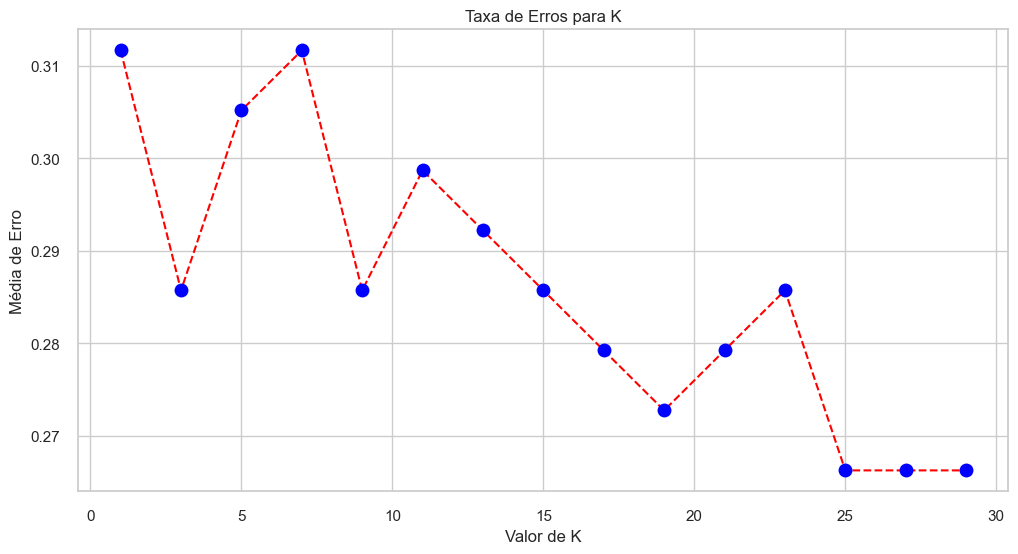

In [34]:
# KNN - PROCURANDO O MELHOR K
# Vamos fazer uma pré avaliação do modelo, pois precisamos saber o K que melhor
# atenderá nosso modelo

# Vamos treinar o modelo e coletar os erros para K entre 1 e 31
# Inicia em 1 vai até 31, sem incluí-lo
# Pega somente valores impares, ou seja, vai de 1 até 29 K vizinhos
error = []
for i in np.arange(1, 31, 2):
  modelo_knn = KNeighborsClassifier(n_neighbors=i)
  modelo_knn.fit(X_train_escalonado, y_train)
  previsao = modelo_knn.predict(X_test_escalonado)
  error.append(np.mean(previsao != y_test))

# Plotar gráfico de linha para verificar qual o melhor K
plt.figure(figsize=(12, 6))
plt.plot(np.arange(1, 31, 2), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Taxa de Erros para K')
plt.xlabel('Valor de K')
plt.ylabel('Média de Erro')

### **Avaliando as taxas de erro**

- Embora valores mais elevados de K (25, 27 e 29) apresentem menor taxa média de erro, observou-se que K=19 proporciona melhor equilíbrio entre desempenho de validação e estabilidade do modelo, evitando underfitting e garantindo maior capacidade de generalização.

- Nossa curva de validação apontão K=15 como melhor e nossa taxa de erro apresentou K=19 como o ideal. Vamos assumir K=19 para nosso treinamento.

In [35]:
# KNN - TREINO DO MODELO COM K = 19

map = {0: 'Não', 1: 'Sim'}

# Cria e treina o modelo
modelo_knn = KNeighborsClassifier(n_neighbors=19)
modelo_knn.fit(X_train_escalonado, y_train)

# Faz uma predição com o primeiro registro do nosso X escalonado
primeiro_registro = X_test_escalonado[[0]]
target_real = y_test.iloc[0] # Primeiro registro do target
print(f'No registro real a paciente tem diabetes?\n {map[target_real]}\n')

# Predição
predicao = modelo_knn.predict(primeiro_registro)[0]

# Valida se o modelo acertou comparando a predição com o dado real
resultado = map[target_real] == map[predicao]

# Imprime os resultados
print(f'O modelo previu a paciente com diabetes?\n {map[predicao]}\n')
print(f'O modelo acertou?\n {map[resultado]}\n')
print(f'Proba:\nChance de não ter Diabetes {modelo_knn.predict_proba(primeiro_registro)[0][0].round(2)}\nChance de ter Diabetes {modelo_knn.predict_proba(primeiro_registro)[0][1].round(2)}')
print(f'Score: {modelo_knn.score(X_test_escalonado, y_test)}')

No registro real a paciente tem diabetes?
 Não

O modelo previu a paciente com diabetes?
 Sim

O modelo acertou?
 Não

Proba:
Chance de não ter Diabetes 0.37
Chance de ter Diabetes 0.63
Score: 0.7272727272727273


### **Interpretando o resultado do treino de KNN K=19**



In [36]:
#PLOTAR GRÁFICO DE FORÇA

# Inicializar Javascript para as visualizações do SHAP
shap.initjs()

# KernelExplainer requer a função de previsão do modelo (predict_proba para classificação)
# e um dataset de background representativo (amostrado para eficiência).
background_data_sample = shap.sample(X_train_escalonado, 100) # Amostra 100 instâncias do treino
s = shap.KernelExplainer(modelo_knn.predict_proba, background_data_sample)

# Obter valores SHAP para a instância de teste selecionada.
shap_vals_instance = s.shap_values(X_test_escalonado[amostra].reshape(1, -1))

amostra = 0 # Testando a primeira paciente do dataset de teste
target_idx = 1 # Tem diabetes

# s.expected_value também é uma lista de valores esperados para cada classe.
# Plota o gráfico para a classe alvo (target_idx).
shap.force_plot(s.expected_value[target_idx],
                np.squeeze(shap_vals_instance[amostra, :, target_idx]),
                X_test_escalonado[amostra,:],
                feature_names=X.columns)

  0%|          | 0/1 [00:00<?, ?it/s]

Da mesma forma que a Regressão Linear, nosso modelo KNN também nos lançou um Falso Positivo, prevendo uma pessoa com doença, sendo que ela não tem. O KNN deu uma probabilidade de 63% de chance da paciente ter a doença, isso mostra que esse modelo é menos cauteloso que o de Regressão Linear que teve probabilidade de 57%.

O gráfico de força tem uma previsão de 0,63. O *base value* é de 0,3321 e representa a probabilidade média da paciente ter a doença.

A dinâmica das variáveis colocam Glucose com um valor acima de 1 desvio padrão, da mesma forma que o modelo de Regressão Linear anterior. SkinThichness, Prenancies e Age aparecem também como fator de risco.

No lado azul, BMI tenta diminuir o risco, mas não tem "força" suficiente para o modelo.

  0%|          | 0/154 [00:00<?, ?it/s]

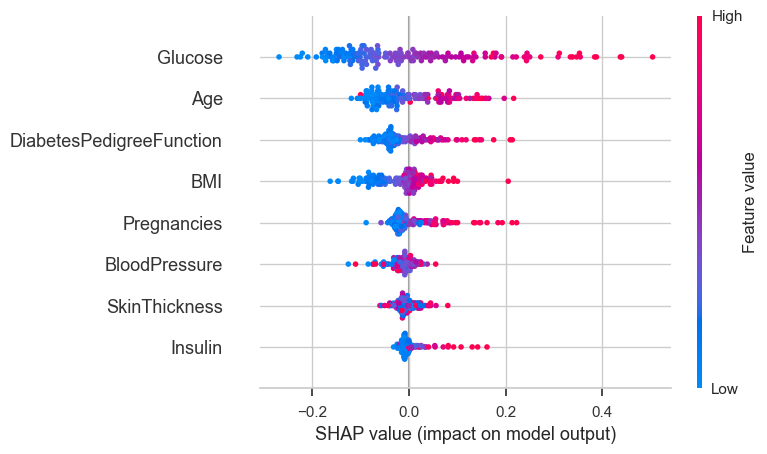

In [37]:
# PLOTAR GRÁFICO SUMÁRIO DAS VARIÁVEIS

# Background dataset para servir de referência.
# Usamos o resumo por k-means para acelerar o cálculo, senão o KernelExplainer demora muito.
background_data = shap.kmeans(X_train_escalonado, 10)

# Criamos o explainer usando a função de probabilidade do KNN
# Passamos modelo_knn.predict_proba para que o SHAP explique a probabilidade final
explainer = shap.KernelExplainer(modelo_knn.predict_proba, background_data)

# Calcular os valores SHAP para o conjunto de teste (ou uma amostra dele)
shap_values = explainer.shap_values(X_test_escalonado)

# KNN (predict_proba), o shap_values retorna uma lista: index [0] para 'Não' e [1] para 'Sim'
# Plotamos o gráfico
shap.summary_plot(shap_values[:, :, 1], X_test_escalonado, feature_names=X.columns)

Mesmo com a mudança do algoritimo, a Glucose permace como a variável mais importante, no entanto é perceptível o espalhamento dos pontos vermelhos à direita do zero. Como o modelo não é linear e sim baseado na vizinhaça não existe uma linha reta de risco. O impacto depende muito dos vizinhos daquela paciente.

Aqui Age aparece em segundo lugar e não mais o BMI, que foi para a quarta posição ficando estranhamente atrás de DiabetesPedigreeFunction. Pode indicar que o KNN encontrou grupos com combinação de idade e histórico familiar que pode ser um preditor de vizinhaça mais forte que o BMI isolado.

Sobre o erro do modelo para o primeiro registro. A paciente tinha glicose e idade altas, pontos vermelhos, no gráfico essas duas variáveis tem uma cauda longa para a direita, a paciente pode ter caído em uma vizinhança onde a maioria das outras pacientes tem essa mesma idade e glicose sendo rotulada como diabética.

### **TERCEIRO MODELO: Árvore de Decisão**

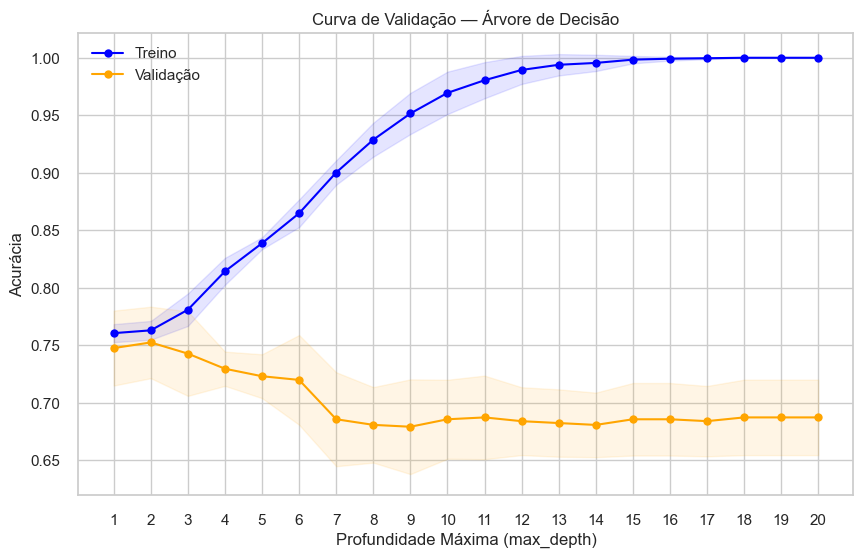

In [38]:
# ÁRVORE DE DECISÃO - TESTAR PARAMETROS E VALIDAR A CURVA DE VALIDAÇÃO

# Para DecisionTreeClassifier o parametro mais importante é o max_depth

# Definir o intervalo de profundidade (de 1 a 20 níveis)
param_range = np.arange(1, 21)

# Calcular a curva de validação
train_scores, test_scores = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_train, y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Calcular médias e desvios padrão
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plotar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(param_range, train_mean, label="Treino", color="blue", marker="o")
plt.plot(param_range, test_mean, label="Validação", color="orange", marker="o")

plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.1, color="orange")

plt.title("Curva de Validação — Árvore de Decisão")
plt.xlabel("Profundidade Máxima (max_depth)")
plt.ylabel("Acurácia")
plt.xticks(param_range)
plt.legend(loc="best")
plt.grid(True)
plt.show()

### **Analisando a Curva de Validação**

- Overfiting. A partir da profundidade 4 há uma separação agressiva entre validação e teste.
- O ponto ótimo é max_depth = 2, onde a acurácia está em 75% e quase encostando na linha de treino. A partir da profundidade 3 o modelo continua aprendendo os dados de treino, mas começa a perder a capacidade de aprender com dados novos.
- A partir de max_depth 15, chega a 100% de acurárica, indicando que o modelo decorou cada registro de treino. Já a validação, cai para 68% de acurácia, indicando que o modelo viciou no ruído de treino e pode falhar com pacientes reais.

In [39]:
# ÁRVORE DE DECISÃO - TREINO DO MODELO COM max_depth = 2

map = {0: 'Não', 1: 'Sim'}

# Cria e treina o modelo
modelo_arvore_decisao = DecisionTreeClassifier(max_depth=2, criterion='entropy', random_state=42)
modelo_arvore_decisao.fit(X_train, y_train)

# Faz uma predição com o primeiro registro do nosso X escalonado
primeiro_registro = X_test.iloc[[0]]
target_real = y_test.iloc[0] # Primeiro registro do target
print(f'No registro real a paciente tem diabetes?\n {map[target_real]}\n')

# Predição
predicao = modelo_arvore_decisao.predict(primeiro_registro)[0]

# Valida se o modelo acertou comparando a predição com o dado real
resultado = map[target_real] == map[predicao]

# Imprime os resultados
print(f'O modelo previu a paciente com diabetes?\n {map[predicao]}\n')
print(f'O modelo acertou?\n {map[resultado]}\n')
print(f'Proba:\nChance de não ter Diabetes {modelo_arvore_decisao.predict_proba(primeiro_registro)[0][0].round(2)}\nChance de ter Diabetes {modelo_arvore_decisao.predict_proba(primeiro_registro)[0][1].round(2)}')
print(f'Score: {modelo_arvore_decisao.score(X_test, y_test)}')

No registro real a paciente tem diabetes?
 Não

O modelo previu a paciente com diabetes?
 Sim

O modelo acertou?
 Não

Proba:
Chance de não ter Diabetes 0.14
Chance de ter Diabetes 0.86
Score: 0.6883116883116883


### **Interpretando os resultados do treinamento**

In [40]:
#PLOTAR GRÁFICO DE FORÇA

# Inicializar Javascript para as visualizações do SHAP
shap.initjs()

s = shap.TreeExplainer(modelo_arvore_decisao)
shap_vals = s.shap_values(X_test)
amostra = 0 # Testando a primeira paciente do dataset de teste
target_idx = 1 # Ter diabetes

# Plota o gráfico
shap.force_plot(s.expected_value[target_idx], shap_vals[amostra, :, target_idx], X_test.iloc[amostra,:], feature_names=X_test.columns)

Novamente, da mesma forma que a Regressão Linear e KNN, a Árvore de Decisão também nos lançou um Falso Positivo, prevendo uma pessoa com doença. O modelo apresentou uma probabilidade de 86% de chance da paciente ter a doença, isso mostra que esse modelo não é confiável para o objetivo que queremos alcançar.

No gráfico de força é possível notar a decisão binária ao extremo. O gráfico está todo vermelho. Houve uma redução de variáveis e o modelo considerou apenas BMI e Glucose como fatores de risco.

In [41]:
# Verificando a importância dos atributos
for col, val in sorted(zip(cols, modelo_arvore_decisao.feature_importances_), key=lambda x: x[1], reverse=True)[:2]:
  print(f'{col:10}{val:10.3f}')

Glucose        0.662
BMI            0.297


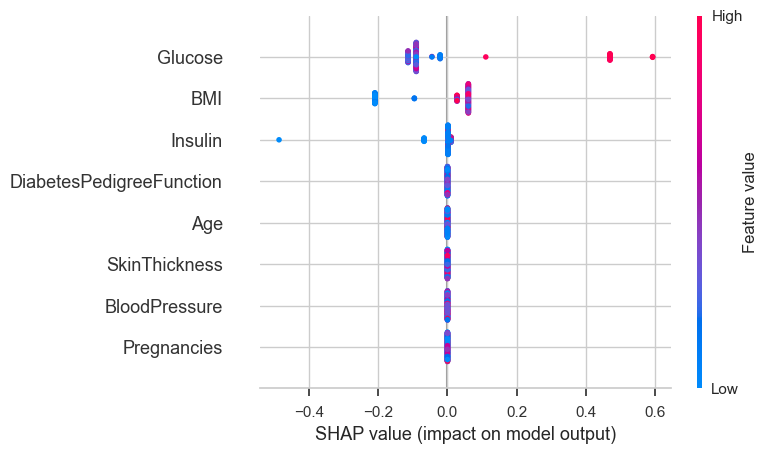

In [42]:
# PLOTAR GRÁFICO SUMÁRIO DAS VARIÁVEIS

# Cria o explainer
explainer = shap.TreeExplainer(modelo_arvore_decisao)

# Calcula os valores SHAP para o conjunto de teste
# Nota: Para Árvores do Scikit-Learn, o SHAP retorna uma lista [classe_0, classe_1]
shap_values = explainer.shap_values(X_test)

# Plotar o gráfico
# Usamos shap_values[1] para focar no que aumenta o risco da doença
target_idx = 1 # Tem diabetes
shap.summary_plot(shap_values[:, :, target_idx], X_test, feature_names=X.columns)

Glucose e BMI não formam um degradê como nos modelos anteriores, os pontos estão concentrados verticalmente, isso ocorre por conta da árvore definir um valor exato para a tomada de decisão.

Também é possível notar que várias variáveis ficaram com os pontos concentrados no zero, ou seja estão sendo descartadas pela árvore.

Porque o modelo errou com uma probabilidade tão alta? A variável de glicose tem um impacto que chega quase a 0,6 no lado direito. A combinação de glicose alta com o valor de massa corporal alta, jogou a paciente em uma folha da árvore com a probabilidade de 86%.

[Text(0.5, 0.8333333333333334, 'Glucose <= 154.5\nentropy = 0.933\nsamples = 614\nvalue = [400, 214]\nclass = Sem Diabetes'),
 Text(0.25, 0.5, 'BMI <= 26.75\nentropy = 0.818\nsamples = 515\nvalue = [384, 131]\nclass = Sem Diabetes'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'entropy = 0.174\nsamples = 115\nvalue = [112, 3]\nclass = Sem Diabetes'),
 Text(0.375, 0.16666666666666666, 'entropy = 0.904\nsamples = 400\nvalue = [272, 128]\nclass = Sem Diabetes'),
 Text(0.75, 0.5, 'Insulin <= 74.9\nentropy = 0.638\nsamples = 99\nvalue = [16, 83]\nclass = Com Diabetes'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'entropy = 0.0\nsamples = 2\nvalue = [2, 0]\nclass = Sem Diabetes'),
 Text(0.875, 0.16666666666666666, 'entropy = 0.595\nsamples = 97\nvalue = [14.0, 83.0]\nclass = Com Diabetes')]

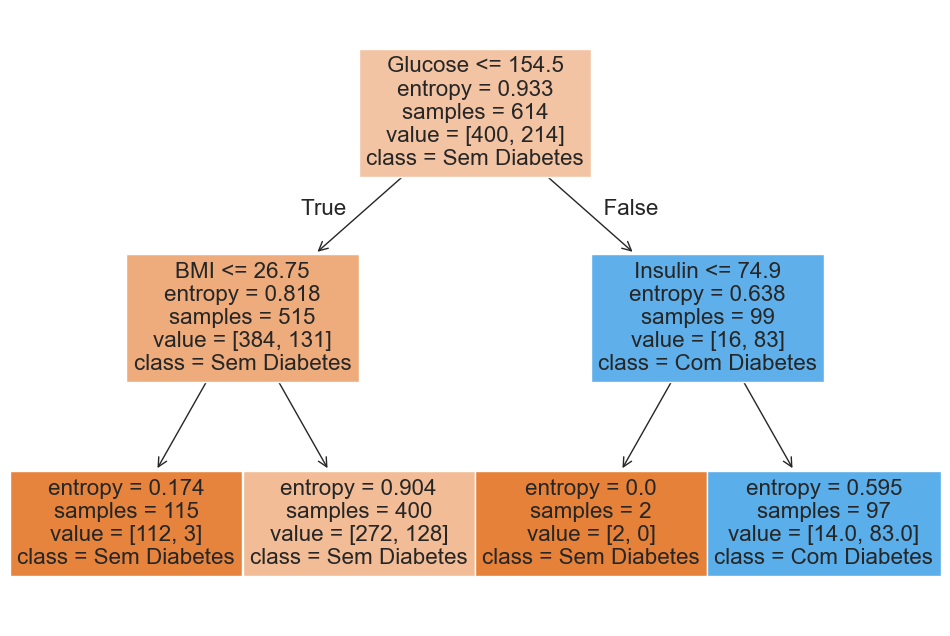

In [43]:
# PLOTAR GRÁFICO ÁRVORE DE DECISÃO
from IPython.display import Image
from sklearn.tree import export_graphviz
from sklearn.tree import plot_tree
from sklearn import tree

# Seta as classes e os nomes das variaveis
class_names = ['Sem Diabetes', 'Com Diabetes']
label_names = X.columns.tolist()

fig, axes = plt.subplots(1, 1, figsize = (12,8))

# Plota a árvore
tree.plot_tree(modelo_arvore_decisao,
               feature_names = label_names,
               class_names=class_names,
               filled = True)

### **Analisando a árvore com o Plot Tree**

Mesmo o modelo já ter apresentado sua ineficácia, vamos analisar as decisões da árvore binária.

**Nó Raiz**

No topo temos o nó raiz com nossa amostra de 614 pacientes. O critério principal do nó raiz é baseado na variável *Glucose*, isso valida que vimos até agora, esta variável é a preditora mais forte. A decisão desse primeiro nó implica em: se o nível de glicose for menor ou igual a 154,5, o modelo segue para o lado esquerdo (true) caso contrário segue para a direita (false). A maioria dos pacientes, 400 dos 614 não possuem diabetes, esse valor é demonstrado em value = [400, 214]. A entropia está muito alta 0.933, quase próxima de 1, isso nos diz que os dados estão muito misturados. Quanto mais próximo de 0 o valor da entropia, mais pura é amostra.

**Lado Esquerdo**

Continuando, se a glicose é baixa o modelo olha para o *BMI*, novamente comprovando o que vimos durante a análise. Se a massa corporal for igual ou inferior a 26,75 o modelo chega a um nó folha, com uma entropia bem precisa de 0.174 apontando que 112 pessoas de 155, não tem propensão ao Diabetes. Já se o IMC for maior que isso, o modelo ainda classifica a amostra como incerta, entropia alta, idicando que embora a maioria não tenha a doença, o risco aumenta.

**Lado Direito**

Seguindo para o lado direito, onde a Glicose é maior que 154,5 o modelo segue para a variável *Insulin*. Se os níveis de insulina são menores ou iguais a 74,9 a previsão é sem diabetes. No entanto, reparmos que a amostra é muito pequena para ser confiável, apenas 2 pacientes. Se a insulina for maior que 74,9 o modelo prevê o paciente com diabetes. Das 97 pacientes nessa amostra, 83 têm a doença, o que representa o caminho com maior probabilidade de diagnóstico positivo.

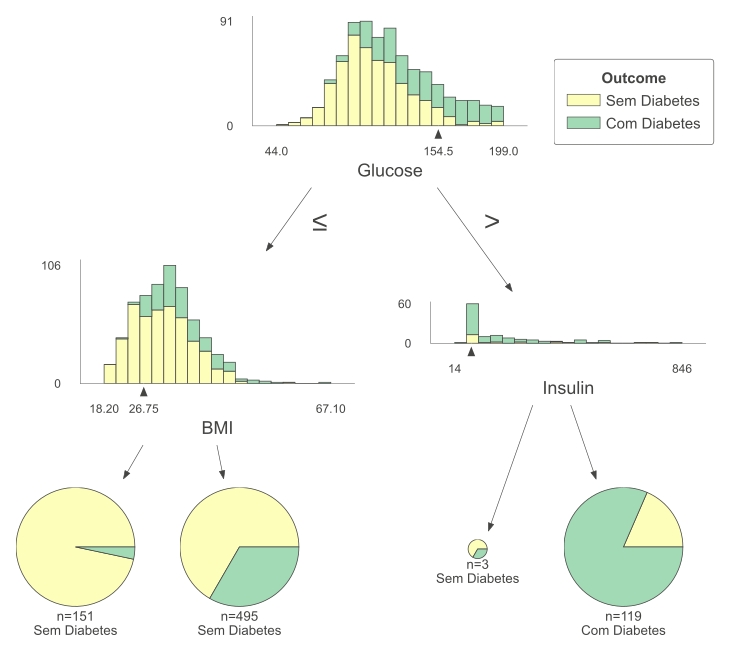

In [44]:
# PLOTAR DTREEVIZ
# Configuração para visualização com o dtreeviz
viz_model = dtreeviz.model(modelo_arvore_decisao,
                           X,
                           y,
                           target_name="Outcome",
                           feature_names=label_names,
                           class_names=class_names,
                           ai_chat=False)

# Renderiza o gráfico
v = viz_model.view(scale=2)
# Plotagem
v

### **Analisando a árvore com o DTreeViz**

Com essa visão, de histogramas e gráficos de pizza a análise fica mais intuítiva.

**Nó Raiz**

Fica nítido no histograma a sobreposição de pacientes com e sem diabetes, mesmo abaixo do ponto de corte de 154,5. Isso explica a entropia alta vista no gráfico anterior, que demostra a mitura dos dados.

**Lado Direito**

O valor 26,75 é um importante divisor, pois a grande maioria dos pacientes abaixo desse número não tem a doença. Na arvore anterior, vimos que a entropia nesse caso estava quase em zero, 0,174.

**Gráficos de Pizza**

O primeiro gráfico a esquerda é quase todo amarelo, indicando a regra de decisão forte, mais uma envidência da entropia próximo a zero. Ou seja, se glicose é baixa e o indice e massa corporal é baixo o risco de diabetes também é baixo.

Já o círculo minúsculo com n = 3 confirma o que notamos no outro gráfico, aquela amostra com apenas duas pacientes. A regra que o modelo criou de glicose alta com insulina baixa, baseada nessa quantidade de dados não pode ser muito confiável.

**Conclusão**
- **Perfil de baixo risco**: glicose menor ou igual 154,5 e IMC menor ou igual a 26,75
- **Perfil de alto risco**: glicose maior que 154,5 e Insulina maior que 74,9

**Resumo compartativo entre os gráficos**
O plotree foca nas regras lógicas enquanto o dtreeviz foca nas evidências visuais.

Insight Clínico: O gráfico sugere que *BMI* só é um fator decisivo de diagnóstico quando a *Glucose* está em níveis normais ou moderados.

Anomalia: O gráfico de Insulina mostra uma cauda longa até o valor de 846, sugerindo que valores extremamente altos de insulina são raros, mas fortemente associados ao diagnóstico positivo.


### **QUARTO MODELO: Floresta Aleatória**


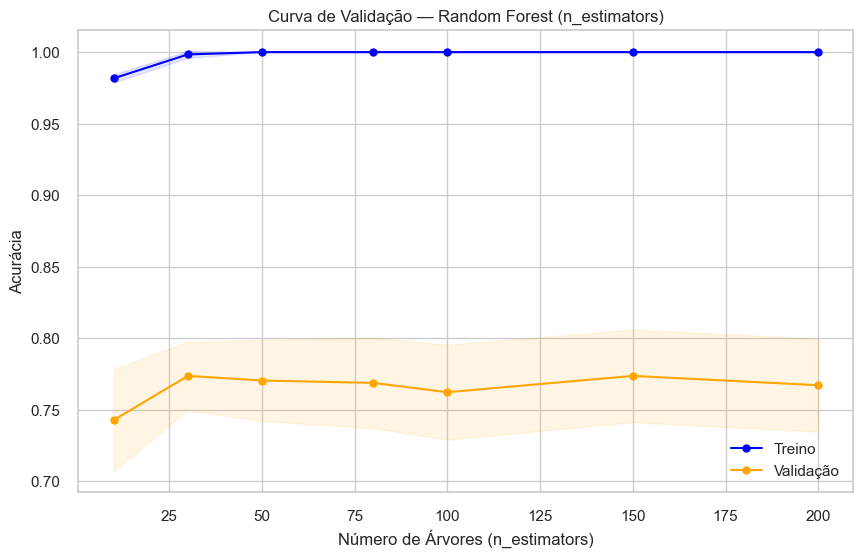

In [45]:
# FLORESTA ALEATÓRIA - TESTAR PARAMETROS E VALIDAR A CURVA DE VALIDAÇÃO

# Definir o intervalo para o número de árvores (ex: de 10 a 200)
param_range = [10, 30, 50, 80, 100, 150, 200]

# Calcular a curva de validação
train_scores, test_scores = validation_curve(
    RandomForestClassifier(random_state=42),
    X_train, y_train,
    param_name="n_estimators",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Cálculo de médias e desvios
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plotar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(param_range, train_mean, label="Treino", color="blue", marker="o")
plt.plot(param_range, test_mean, label="Validação", color="orange", marker="o")

plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.1, color="orange")

plt.title("Curva de Validação — Random Forest (n_estimators)")
plt.xlabel("Número de Árvores (n_estimators)")
plt.ylabel("Acurácia")
plt.legend(loc="best")
plt.grid(True)
plt.show()

### **Analisando a Curva de Validação**

- O modelo atinge o platô de acurácia de validação muito cedo, por volta das 30 árvores. Mesmo aumentando para 200 árvores, a acurácia de validação permanece estável em ~77%. Isso nos mostra que adicionar mais árvores não não causa overfiting, apenas estabiliza a variância.
- Assim como os modelos de Regressão Logística e KNN a Floresta Aleatória também encontra seu limite próximo a 80%.
- O gap entre a linha de treino e validação representa a genarilização, este é o comportamento esperado em Florestas Aleatórias. Cada arvore individual decora parte do dataset, mas na média final mantém a validação alta e estável.

Como outros hiperparámetros podem afetar o modelo, vamos usar na próxima célula a técnica de GridSearchCV para obtermos os melhores parametros para o modelo.

In [46]:
# FLORESTA ALEATÓRIA - GRIDSEARCHCV

# Como temos muitos hiperparametros que podem impactar no nosso modelo
# Vamos usar GridSearchCV
param_grid = {
    "n_estimators": [30, 50],   # já vimos que mais não ajuda na análise de curva de validação
    "max_depth": [None, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Melhores hiperparâmetros:")
print(grid.best_params_)

print("\nMelhor acurácia (CV):")
print(grid.best_score_)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Melhores hiperparâmetros:
{'max_depth': 15, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 30}

Melhor acurácia (CV):
0.7866586698653871


In [47]:
# FLORESTA ALEATÓRIA - TREINO DO MODELO COM:
#max_depth=15, max_features='log2', min_samples_leaf=1, min_samples_split=5, n_estimators=30

map = {0: 'Não', 1: 'Sim'}

# Cria o modelo com o melhor grid e treina
#modelo_floresta_aleatoria = RandomForestClassifier(max_depth=2, n_estimators=6, criterion='entropy', random_state=42)
#modelo_floresta_aleatoria.fit(X_train, y_train)
modelo_floresta_aleatoria = grid.best_estimator_

# Faz uma predição com o primeiro registro do nosso X escalonado
primeiro_registro = X_test.iloc[[0]]
target_real = y_test.iloc[0] # Primeiro registro do target
print(f'No registro real a paciente tem diabetes?\n {map[target_real]}\n')

# Predição
predicao = modelo_floresta_aleatoria.predict(primeiro_registro)[0]

# Valida se o modelo acertou comparando a predição com o dado real
resultado = map[target_real] == map[predicao]

# Imprime os resultados
print(f'O modelo previu a paciente com diabetes?\n {map[predicao]}\n')
print(f'O modelo acertou?\n {map[resultado]}\n')
print(f'Proba:\nChance de não ter Diabetes {modelo_floresta_aleatoria.predict_proba(primeiro_registro)[0][0].round(2)}\nChance de ter Diabetes {modelo_floresta_aleatoria.predict_proba(primeiro_registro)[0][1].round(2)}')
print(f'Score: {modelo_floresta_aleatoria.score(X_test, y_test)}')

No registro real a paciente tem diabetes?
 Não

O modelo previu a paciente com diabetes?
 Sim

O modelo acertou?
 Não

Proba:
Chance de não ter Diabetes 0.32
Chance de ter Diabetes 0.68
Score: 0.7532467532467533


### **Interpretando o resultado do treinamento**

In [48]:
#PLOTAR GRÁFICO DE FORÇA

# Inicializar Javascript para as visualizações do SHAP
shap.initjs()

s = shap.TreeExplainer(modelo_floresta_aleatoria)
shap_vals = s.shap_values(X_test)
amostra = 0 # Testando a primeira paciente do dataset de teste
target_idx = 1 # Ter diabetes

# Plota o gráfico
shap.force_plot(s.expected_value[target_idx], shap_vals[amostra, :, target_idx], X_test.iloc[amostra,:], feature_names=X_test.columns)

Repetindo o cenário dos 3 primeiros modelos, a Floresta Aleatória também errou a previsão do primeiro paciente. O fato de todos os modelos terem errado esse registro demonstra alguma evidência de ruído nos dados ou algum caso atípico.

Ao analisar a probabilidade atribuída ao erro para este primeiro registro (paciente saudável), vemos uma gradação interessante entre os modelos:

Árvore de Decisão: Errou com 86% de confiança (muito extremo).

Random Forest: Errou com 68% de confiança (moderada).

KNN: Errou com 63% de confiança.

Regressão Logística: Errou com 57% de confiança (a mais cautelosa).

O gráfico de força explica as variáveis de risco Glucose, Age e Pregnanceis jogando a probabilidade para a direita, para longe do valor base de 0,3452, o BMI é a única força relevante para puxar a predição para baixo mas não tem força suficiente.


In [49]:
# Verificando a importância das variáveis
for col, val in sorted(zip(cols, modelo_floresta_aleatoria.feature_importances_), key=lambda x: x[1], reverse=True)[:8]:
  print(f'{col:10}{val:10.3f}')

Glucose        0.290
BMI            0.168
Age            0.145
DiabetesPedigreeFunction     0.124
Insulin        0.081
Pregnancies     0.068
BloodPressure     0.064
SkinThickness     0.060


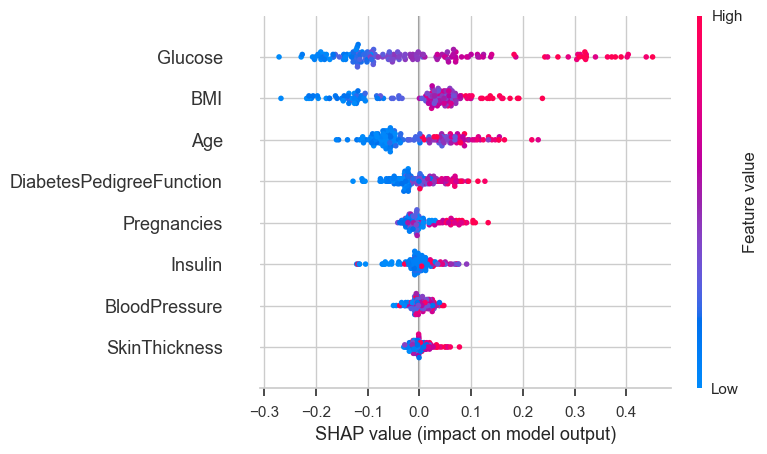

In [50]:
# PLOTAR GRÁFICO SUMÁRIO DAS VARIÁVEIS

# Cria o explainer
explainer = shap.TreeExplainer(modelo_floresta_aleatoria)

# Calcula os valores SHAP para o conjunto de teste
# Nota: Para Árvores do Scikit-Learn, o SHAP retorna uma lista [classe_0, classe_1]
shap_values = explainer.shap_values(X_test)

# Plotar o gráfico
# Usamos shap_values[1] para focar no que aumenta o risco da doença
target_idx = 1 # Tem diabetes
shap.summary_plot(shap_values[:, :, target_idx], X_test, feature_names=X.columns)

O modelo classificou as variáveis *Glucose* e *BMI* com maior valor de importância para redução de erro. Mais uma vez, a glicose e o indice de massa aparecem como os melhores preditores.

No gráfico, torna-se clara a diferença entre esse modelo e a árvore simples que tem os dados mais rígidos e isolados, a floresta aleatória mostar a distribuição mais densa e contínua dos pontos, prova de que modelos de conjunto conseguem captar detalhes sutis nos dados.

O gráfico também reafirma as três variáveis que estão a frente do risco de diabetes. Glucose continua sendo a mais importante, os pontos vermelhos estão fortemente deslocados para a direita, aumentando o impacto no modelo. BMI se consolida como sendo o segundo. No gráfico de força vimos que BMI baixo tenta salvar a paciente do erro do modelo e aqui dá para perceber que é uma tendência do modelo, representado pelos pontos azuis de BMI baixo. A idade vem em terceiro, mostrando que valores altos, tem impacto positivo no risco, mas de forma menos relevante do que a glicose.

Na próxima sessão iremos avaliar nossos modelos e compará-los entre si para chegarmos ao melhor modelo

# 4. AVALIAÇÃO DOS MODELOS E ESCOLHA DO MELHOR

Para avaliar nossos modelos, vamos:
1. plotar as matriz de confusão
2. validar as acurácias
3. plotar os relatórios de classificação (precision, recall, f1-score)
4. plotar as curvas ROC

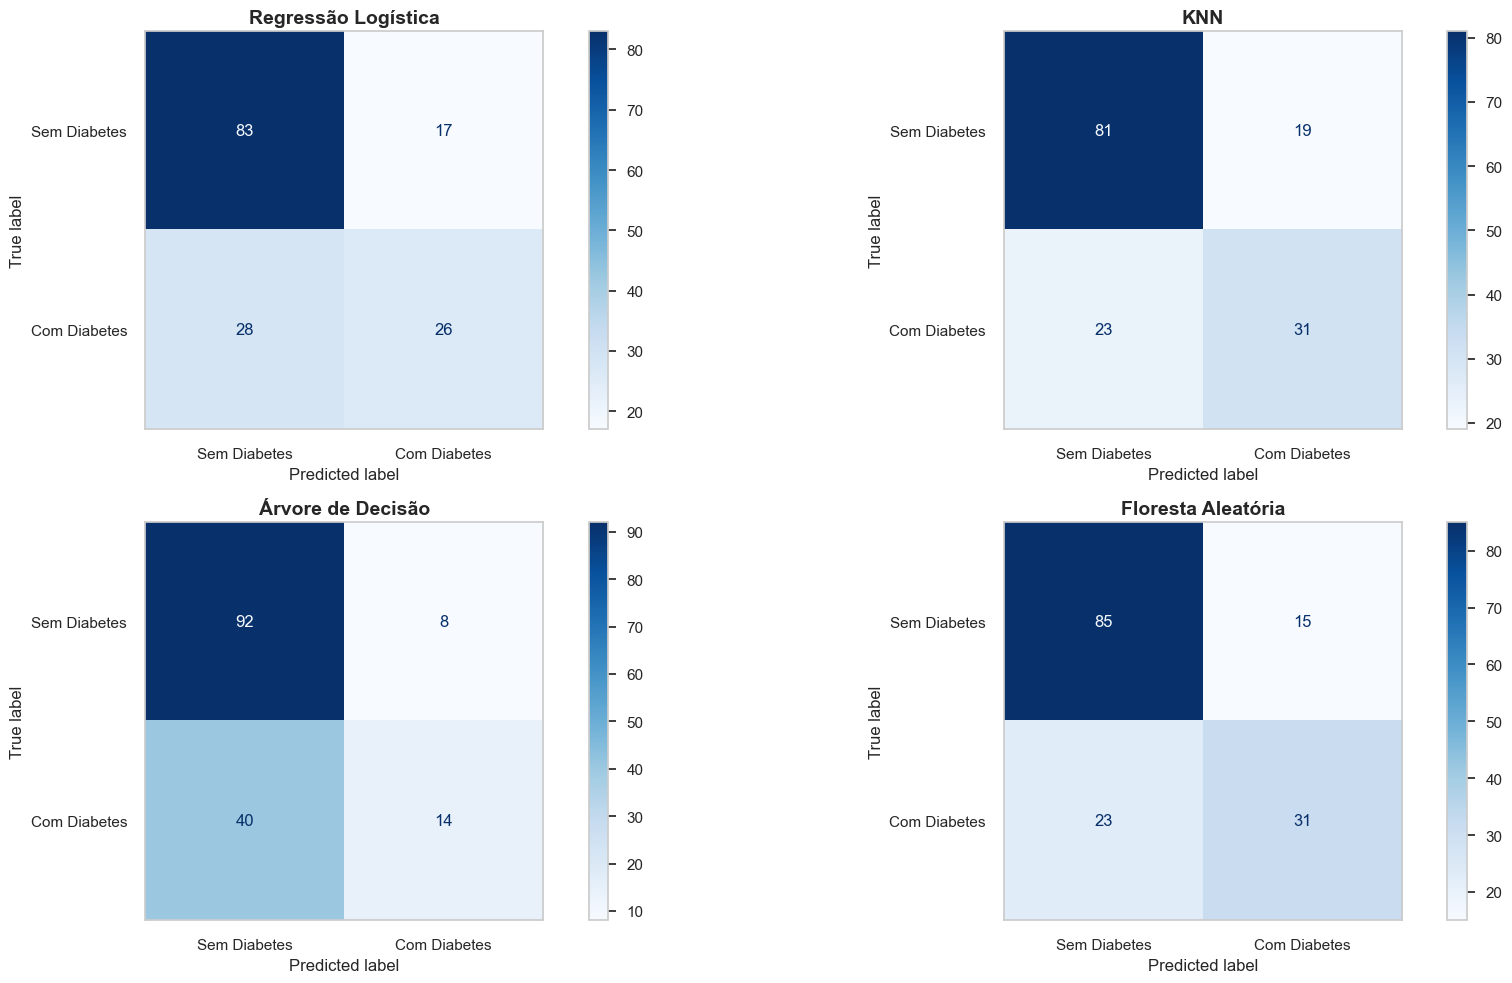

In [51]:
# PLOTAR MATRIZ DE CONFUSÃO PARA OS MODELOS

# Matriz de confusão
from sklearn.metrics import ConfusionMatrixDisplay

# Modelos
modelos = [modelo_regressao_logistica, modelo_knn, modelo_arvore_decisao, modelo_floresta_aleatoria]
modelos_nomes = ["Regressão Logística", "KNN", "Árvore de Decisão", "Floresta Aleatória"]

# Criar uma grade de 2 linhas e 2 colunas
fig, axes = plt.subplots(2, 2, figsize=(18, 10), dpi=100)
axes = axes.flatten()

# Loop para plotar cada matriz
for i, modelo in enumerate(modelos):
    # Para os modelos de árvores, utilizei os dados originais
    if "Árvore" in modelos_nomes[i] or "Floresta" in modelos_nomes[i]:
        X_avaliacao = X_test
    else:
        X_avaliacao = X_test_escalonado

    ConfusionMatrixDisplay.from_estimator(
        modelo,
        X_avaliacao,
        y_test,
        display_labels=['Sem Diabetes', 'Com Diabetes'],
        cmap='Blues',
        ax=axes[i]
    )
    axes[i].set_title(modelos_nomes[i], fontsize=14, fontweight='bold')
    axes[i].grid(False) # Remove linhas de grade internas para clareza

plt.tight_layout()
plt.show()

### **Avaliando a Matriz de Confusão**

**Floresta Aleatória e KNN**: apresentam equilíbrio

Ambos identificam corretamente 31 pacientes com diabetes (verdadeiro positivo). É o maior número entre todos os modelos. Tiveram 23 erros ao classificar doentes como saudáveis (falso negativo). Mesmo o número de erros tendo sido menor entre todos os modelos, em saúde, esse número precisa ser reduzido ainda mais.

**Regressão Logística**: conservador

Classificou 17 pacientes saudáveis com diabéticas (falso positivo). Embora tenha um desempenho ligeiramente inferior 26 acertos em doentes ela é o modelo mais equilibrado como vimos na curva de validação.

**Árvore de Decisão**: alto índice de falsos negativos classificou 40 diabéticas como saudáveis. Ela é enganosa, parece ótima em classificar saudáveis, mas falha no objetivo principal que é a detecção da doença.

Vamos continuar nossa avaliação validando as métricas de acurácia, precision, recall e f1-score

In [52]:
# Apresentando a acurácia
from sklearn.metrics import accuracy_score

print('--- ACURÁCIA DOS MODELOS ---')
for i, modelo in enumerate(modelos):
    # Para os modelos de árvores, utilizei os dados originais
    if "Árvore" in modelos_nomes[i] or "Floresta" in modelos_nomes[i]:
        X_avaliacao = X_test
    else:
        X_avaliacao = X_test_escalonado

    y_predito = modelo.predict(X_avaliacao)

    # Calcula a acurácia
    acuracia = accuracy_score(y_test, y_predito)
    print(f"{modelos_nomes[i]:<20}: {acuracia:.2%}")

--- ACURÁCIA DOS MODELOS ---
Regressão Logística : 70.78%
KNN                 : 72.73%
Árvore de Decisão   : 68.83%
Floresta Aleatória  : 75.32%


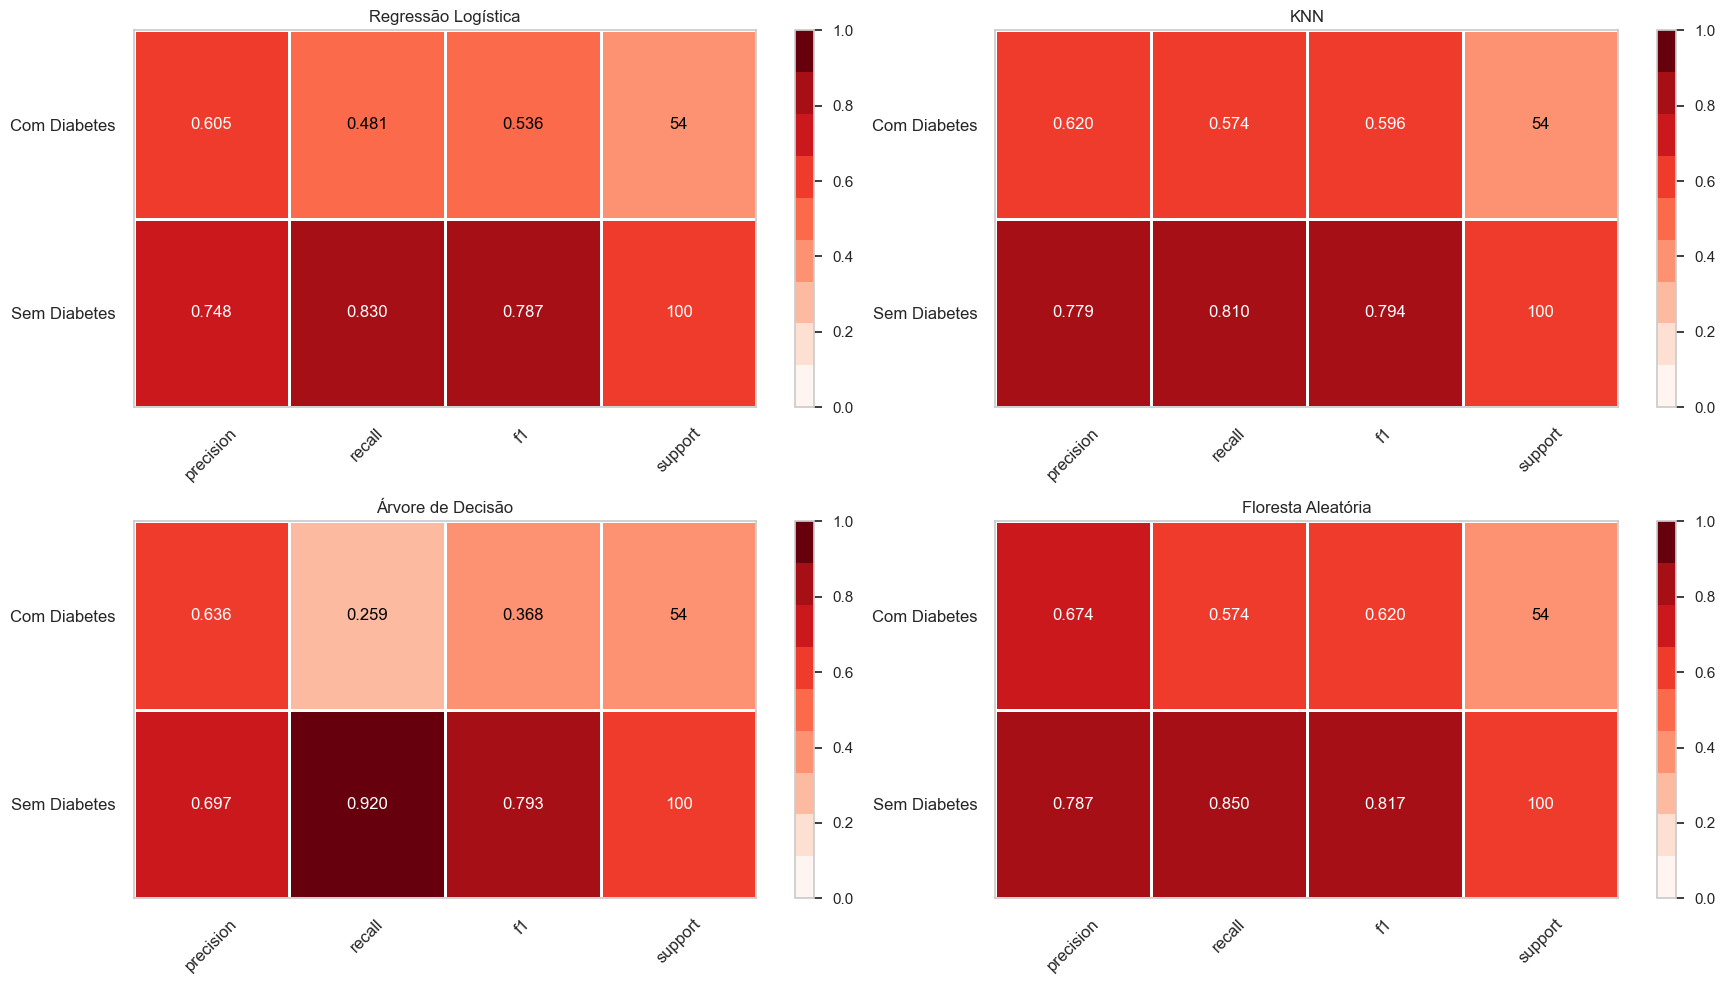

In [53]:
# Montar os relatórios de classificação e plotar em uma grade
from yellowbrick.classifier import ClassificationReport

def gerar_relatorio_visual(modelo, nome_modelo, X_avaliacao, y_avaliacao, ax):

      # Extrai o estimador se for um Pipeline
    if hasattr(modelo, 'named_steps'):
        estimador = modelo.named_steps['modelo_svc']
    else:
        estimador = modelo

    # Instancia o visualizador
    relatorio_classificacao = ClassificationReport(
        estimador,
        classes=class_names,
        support=True,
        cmap='Reds',
        ax=ax,
        title=nome_modelo,
        force_model=True
    )

    # Ajusta e renderiza o gráfico
    relatorio_classificacao.score(X_avaliacao, y_avaliacao)
    relatorio_classificacao.finalize()


fig, axes = plt.subplots(2, 2, figsize=(18, 10), dpi=100)
axes = axes.flatten()

# Loop para plotar cada relatorio
for i, modelo in enumerate(modelos):
    # Para os modelos de árvores, utilizei os dados originais
    if "Árvore" in modelos_nomes[i] or "Floresta" in modelos_nomes[i]:
        X_avaliacao = X_test
    else:
        X_avaliacao = X_test_escalonado

    gerar_relatorio_visual(modelo, modelos_nomes[i], X_avaliacao, y_test, axes[i])

plt.tight_layout()
plt.show()

### **Avaliando as Acurácias e os Relatórios de Classificação**

#### **Acurácia**

A acurácia melhorou ao longo dos treinamentos com os diferentes modelos, de 68,8% (árvore de decisão) para 75,3% (floresta aleatória).

#### **Desempenho por Métrica**

**Precision**: indica a qualidade das previsões positivas

A **Floresta Aleatória** lidera para a classe "Com Diabetes" com 0,674, significando que quando ela diz que alguém tem a doença, ela está certa em cerca de 67% das vezes.

O **KNN** e a **Regressão Logística** têm precisões menores, 0,620 e 0,605 respectivamente, gerando mais alarmes falsos.

**Recall**: indica a capacidade de encontrar todos os casos positivos

O **KNN** e a **Floresta Aleatória** aparecem empatados neste quesito com 0,574. Isso confirma nossa análise anterior, são os melhores modelos para triagem, pois identifica a maior proporção de doentes reais.

A **Árvore de Decisão** tem um recall baixíssimo de 0,259, deixando passar quase 75% dos pacientes diabéticos sem diagnóstico.

**F1-Score**: é a média harmônica entre Precision e Recall, ideal para comparar modelos de forma equilibrada.

Para a classe "Com Diabetes", o **Floresta Aleatória** com 0,620 apresenta o melhor equilíbrio geral, seguido pelo **KNN** com 0,596.

#### **Conclusão do Diagnóstico de Dados**

**Desequilíbrio de Suporte**: temos 100 casos "Sem Diabetes" para apenas 54 casos "Com Diabetes" (Support). Esse desequilíbrio explica por que todos os modelos têm métricas muito melhores para a classe negativa do que para a positiva.

**Vencedor Técnico**: A **Floresta Aleatória** é o modelo mais confiável em termos de F1-score de 0,620 para a classe com diabetes e 0,817 para sem diabetes, os valores mais consistentes entre todos os modelos.

Vamos agora analisar as curvas ROC dos modelos e finalizar nossa avaliação

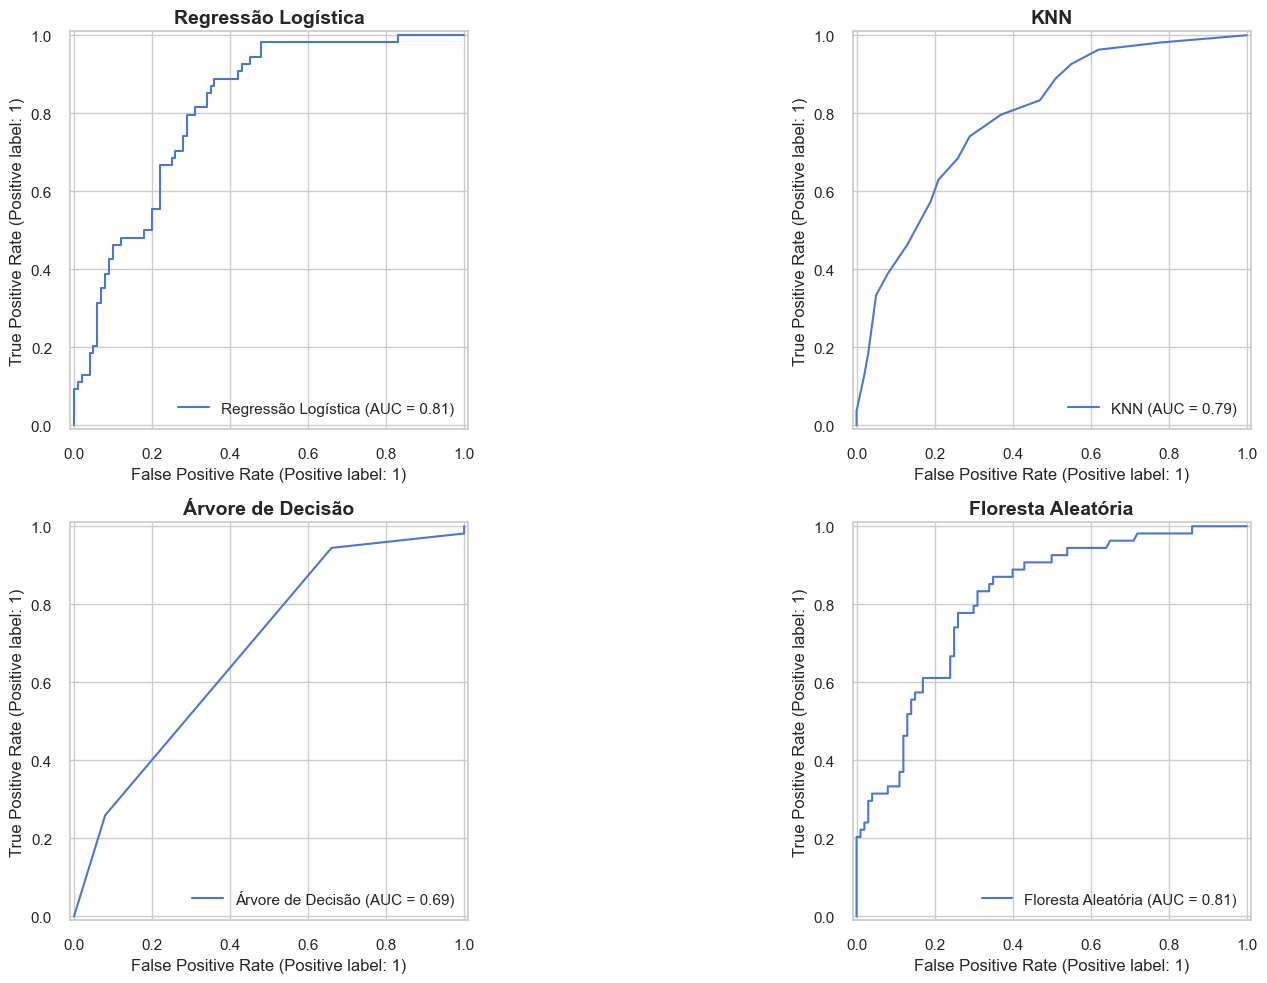

In [54]:
# PLOTAR AS CURVAS ROC DOS MODELOS
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(2, 2, figsize=(18, 10), dpi=100)
axes = axes.flatten()

# Loop para plotar cada curva ROC
for i, modelo in enumerate(modelos):
    # Para os modelos de árvores, utilizei os dados originais
    if "Árvore" in modelos_nomes[i] or "Floresta" in modelos_nomes[i]:
        X_avaliacao = X_test
    else:
        X_avaliacao = X_test_escalonado

    # Usa RocCurveDisplay do scikit-learn
    RocCurveDisplay.from_estimator(
        modelo,
        X_avaliacao,
        y_test,
        ax=axes[i],
        name=modelos_nomes[i]
    )
    axes[i].set_title(f'{modelos_nomes[i]}', fontsize=14, fontweight='bold')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

### **Avaliando as Curvas ROC**

#### **Ranking de Desempenho (AUC)**

A métrica AUC resume a qualidade do modelo em um único número de 0 a 1. Quanto mais próximo de 1, melhor o modelo distingue entre pacientes com e sem diabetes.

**Floresta Aleatória** (AUC = 0,81) e **Regressão Logística** (AUC = 0,81): empataram com o melhor AUC. Isso indica uma excelente capacidade discriminatória para ambos os algoritmos.

**KNN** (AUC = 0,79): desempenho sólido, ligeiramente inferior aos líderes, mas consistente com a estabilidade vista na sua curva de validação.

**Árvore de Decisão** (AUC = 0,69): É o modelo com o desempenho mais fraco. A curva é composta por apenas dois segmentos retos principais, refletindo a natureza binária das decisões tomadas por uma única árvore.


| Modelo               | Acurácia | AUC  | Comportamento SHAP                          | Conclusão                         |
|----------------------|----------|------|---------------------------------------------|-----------------------------------|
| Floresta Aleatória   | 75.32%   | 0,81 | Equilibrado                     | O melhor modelo global.            |
| KNN                  | 72,73%   | 0,79 | Sensível à vizinhança               | Melhor para triagem inicial.       |
| Regressão Logística  | 70.78%   | 0,81 | Linear e focado em Glicose                  | Bom para entender relações diretas |
| Árvore de Decisão    | 68,83%   | 0,69 | Simplista e enviesado               | Muito instável para uso clínico.   |

Vamos tentar melhorar nosso modelo de Floresta Aleatória para essa acurácia ficar pelo menos acima dos 80%. Usaremos a técnica de SMOTE na nossa base de treino para tratar o desbalanceamento das classes, onde temos mais casos negativos do que positivos de diabetes. Repetiremos toda a fase de treinamento do modelo RandomForest e sua avaliação.


# 5. MELHORANDO O MODELO VENCEDOR

In [55]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Instanciando o SMOTE
# random_state garante que os dados sintéticos sejam os mesmos toda vez que rodar
sm = SMOTE(random_state=42)

print(f"Antes do SMOTE: {Counter(y_train)}")

# Aplicando apenas ao conjunto de TREINO sobrescreve nossos dados de treino
X_train, y_train = sm.fit_resample(X_train, y_train)

print(f"Depois do SMOTE: {Counter(y_train)}")

Antes do SMOTE: Counter({0: 400, 1: 214})
Depois do SMOTE: Counter({0: 400, 1: 400})


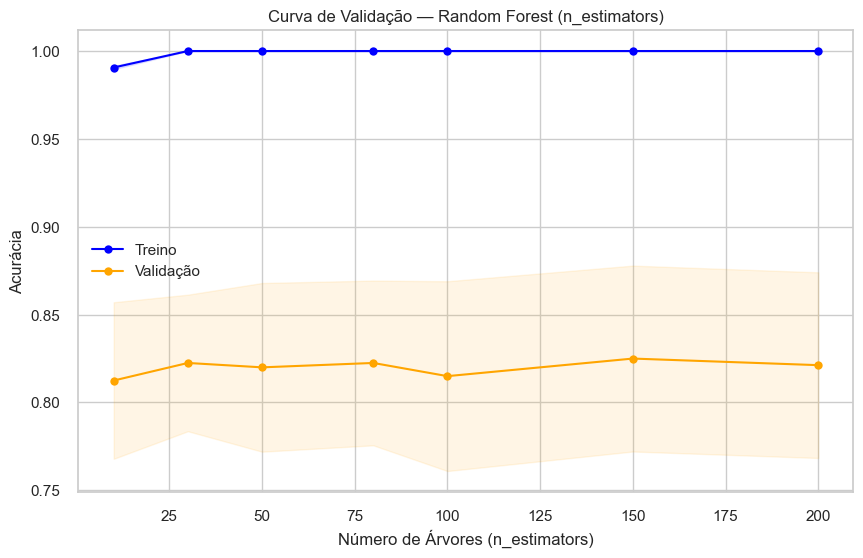

In [56]:
# FLORESTA ALEATÓRIA USANDO SMOTE - TESTAR PARAMETROS E VALIDAR A CURVA DE VALIDAÇÃO

# Definir o intervalo para o número de árvores (ex: de 10 a 200)
param_range = [10, 30, 50, 80, 100, 150, 200]

# Calcular a curva de validação
train_scores, test_scores = validation_curve(
    RandomForestClassifier(random_state=42),
    X_train, y_train,
    param_name="n_estimators",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Cálculo de médias e desvios
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plotar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(param_range, train_mean, label="Treino", color="blue", marker="o")
plt.plot(param_range, test_mean, label="Validação", color="orange", marker="o")

plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.1, color="orange")

plt.title("Curva de Validação — Random Forest (n_estimators)")
plt.xlabel("Número de Árvores (n_estimators)")
plt.ylabel("Acurácia")
plt.legend(loc="best")
plt.grid(True)
plt.show()

Percebemos uma melhora na acurácia após o SMOTE, mas também a área sombreada laranja ficou mais larga, mostrando uma variância maior. Vamos agora fazer novamente o GridSearchCV em busca dos melhores hiperametros.

In [57]:
# FLORESTA ALEATÓRIA USANDO SMOTE - GRIDSEARCHCV

# Como temos muitos hiperparametros que podem impactar no nosso modelo
# Vamos usar GridSearchCV
param_grid = {
    "n_estimators": [30, 50],   # já vimos que mais não ajuda na análise de curva de validação
    "max_depth": [None, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Melhores hiperparâmetros:")
print(grid.best_params_)

print("\nMelhor acurácia (CV):")
print(grid.best_score_)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Melhores hiperparâmetros:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 30}

Melhor acurácia (CV):
0.8225


Os hiperparametros mudaram após o SMOTE. O resultado do Grid também nos apresenta a melhor acurácia, de 82% um ganho de 7% em relação ao treino anterior. Essa acurácia ainda não representa nosso modelo, pois ela trata de dados específicos de treino usados pelo grid.

Vamos avaliar o modelo novamente.

In [58]:
# FLORESTA ALEATÓRIA - TREINO DO MODELO COM:
#max_depth=None, max_features='sqrt', min_samples_leaf=1, min_samples_split=2, n_estimators=30

map = {0: 'Não', 1: 'Sim'}

# Cria o modelo com o melhor grid e treina
modelo_floresta_aleatoria = grid.best_estimator_
modelo_floresta_aleatoria.fit(X_train, y_train)

# Faz uma predição com o primeiro registro do nosso X escalonado
primeiro_registro = X_test.iloc[[0]]
target_real = y_test.iloc[0] # Primeiro registro do target
print(f'No registro real a paciente tem diabetes?\n {map[target_real]}\n')

# Predição
predicao = modelo_floresta_aleatoria.predict(primeiro_registro)[0]

# Valida se o modelo acertou comparando a predição com o dado real
resultado = map[target_real] == map[predicao]

# Imprime os resultados
print(f'O modelo previu a paciente com diabetes?\n {map[predicao]}\n')
print(f'O modelo acertou?\n {map[resultado]}\n')
print(f'Proba:\nChance de não ter Diabetes {modelo_floresta_aleatoria.predict_proba(primeiro_registro)[0][0].round(2)}\nChance de ter Diabetes {modelo_floresta_aleatoria.predict_proba(primeiro_registro)[0][1].round(2)}')
print(f'Score: {modelo_floresta_aleatoria.score(X_test, y_test)}')

No registro real a paciente tem diabetes?
 Não

O modelo previu a paciente com diabetes?
 Sim

O modelo acertou?
 Não

Proba:
Chance de não ter Diabetes 0.27
Chance de ter Diabetes 0.73
Score: 0.7272727272727273


### **Interpretando o resultado do treinamento após SMOTE**

In [59]:
#PLOTAR GRÁFICO DE FORÇA

# Inicializar Javascript para as visualizações do SHAP
shap.initjs()

s = shap.TreeExplainer(modelo_floresta_aleatoria)
shap_vals = s.shap_values(X_test)
amostra = 0 # Testando a primeira paciente do dataset de teste
target_idx = 1 # Ter diabetes

# Plota o gráfico
shap.force_plot(s.expected_value[target_idx], shap_vals[amostra, :, target_idx], X_test.iloc[amostra,:], feature_names=X_test.columns)

O modelo continua errando a previsão do primeiro paciente do nosso dataset de testes. Aparentemente o modelo está viciado decorando ruídos.

In [60]:
# Verificando a importância das variáveis
for col, val in sorted(zip(cols, modelo_floresta_aleatoria.feature_importances_), key=lambda x: x[1], reverse=True)[:8]:
  print(f'{col:10}{val:10.3f}')

Glucose        0.250
BMI            0.191
DiabetesPedigreeFunction     0.123
Age            0.121
BloodPressure     0.093
Insulin        0.084
SkinThickness     0.078
Pregnancies     0.061


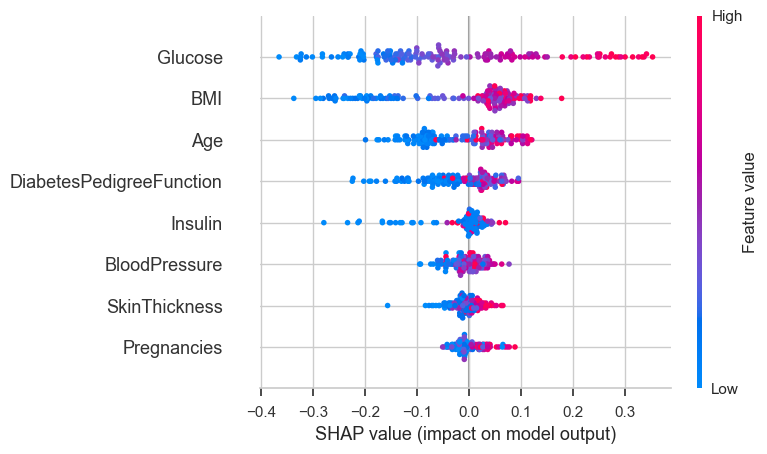

In [61]:
# PLOTAR GRÁFICO SUMÁRIO DAS VARIÁVEIS

# Cria o explainer
explainer = shap.TreeExplainer(modelo_floresta_aleatoria)

# Calcula os valores SHAP para o conjunto de teste
# Nota: Para Árvores do Scikit-Learn, o SHAP retorna uma lista [classe_0, classe_1]
shap_values = explainer.shap_values(X_test)

# Plotar o gráfico
# Usamos shap_values[1] para focar no que aumenta o risco da doença
target_idx = 1 # Tem diabetes
shap.summary_plot(shap_values[:, :, target_idx], X_test, feature_names=X.columns)

Houve mudanças na importância das variáveis
- Glucose: mudou de 0.290 para 0.250
- BMI: ganhou mais pontos foi de 0.168 para 0.191
- Age: diminui sua importância indo de 0.145 para 0.121
- DiabetesPedigreeFunction: ganhou uma posição, passou de Age indo de 0.124 para 0.123
- BloodPressure: também ganhou posição passando de Insulin

O gráfico sumário do SHAP também nos mostra isso. Inclusive ele parece muito mais equilibrado agora, os pontos para a direita e para esquerda estão em equilíbrio, demonstrando o balanceamento da nossa base de treino. A variável Glucose está bem mais compacta com os pontos unidos, diferente do gráfico sem SMOTE que mostrava uma disperção de pontos em direção a direita.

### MATRIZ DE CONFUSÃO APÓS APLICAÇÃO DO SMOTE

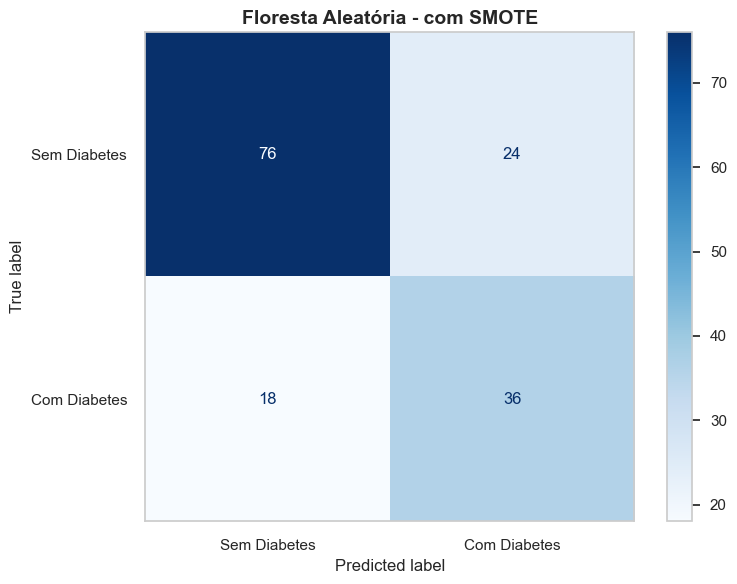

In [62]:
# Criar uma grade
fig, axes = plt.subplots(1, 1, figsize=(8, 6), dpi=100)

ConfusionMatrixDisplay.from_estimator(
        modelo_floresta_aleatoria,
        X_test,
        y_test,
        display_labels=['Sem Diabetes', 'Com Diabetes'],
        cmap='Blues',
        ax=axes
    )

axes.set_title("Floresta Aleatória - com SMOTE", fontsize=14, fontweight='bold')
axes.grid(False)

plt.tight_layout()
plt.show()

### **Avaliando a Matriz de Confusão após o SMOTE**

Anteriormente, **sem o SMOTE** o modelo acertou 31 diábeticos e errou 23 (falsos negativos), já **com o SMOTE** o modelo acertou 36 e errou apenas 18, indicando uma melhora no recall. Reduzimos o erro mais perigoso da área da saúde, dizer que um doente é saudável.

Em contrapartida, o modelo começa a dar mais alarmes falsos, onde **sem SMOTE** tivemos apenas 15 falsos positivos (pacientes saudáveis classificadas como doentes) e **com SMOTE** o número subiu para 24, ou seja, a precisão caiu o que indica que quando o modelo diz que a pessoa tem diabetes, há uma chance maior de estar errando.

### ACURÁCIA E RELATÓRIO DE CLASSIFICAÇÃO APÓS APLICAÇÃO DO SMOTE

In [63]:
# ACURÁCIA APÓS O SMOTE
y_predito = modelo_floresta_aleatoria.predict(X_test)
acuracia = accuracy_score(y_test, y_predito)
print(f"Floresta Aleatória: {acuracia:.2%}")

Floresta Aleatória: 72.73%


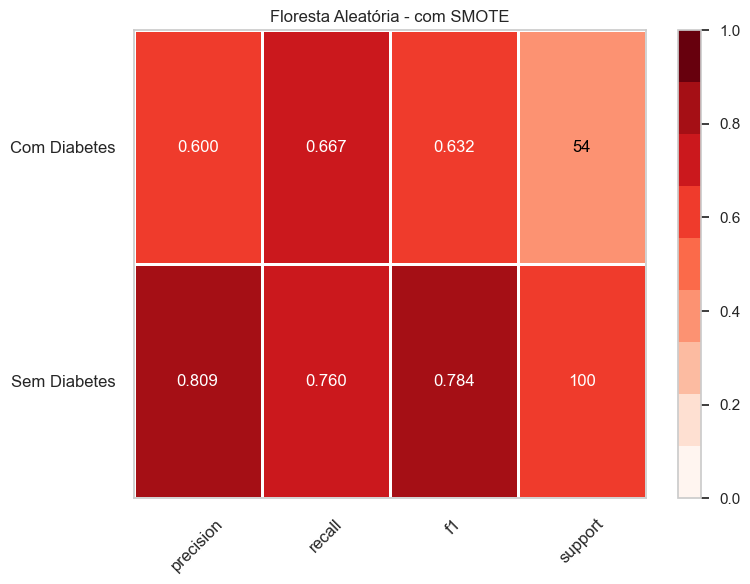

In [64]:
# RELATÓRIO DE CLASSIFCAÇÃO APÓS O SMOTE
fig, axes = plt.subplots(1, 1, figsize=(8, 6), dpi=100)

# Cria o relatório
gerar_relatorio_visual(modelo_floresta_aleatoria, "Floresta Aleatória - com SMOTE", X_test, y_test, axes)

plt.tight_layout()
plt.show()

### **Avaliando a Acurácia e o Relatório de Classificação após o SMOTE**

Sobre a acurácia, o modelo com acurácia abaixo do modelo anterior sem SMOTE. O treinamento anterior chegou a 75,32% de acurácia, enquanto o modelo treinado com SMOTE chegou a 72,73% empatando com o KNN.

Para  a classe Com Diabetes:

O **Recall** melhorou, teve um salto de 0,574 para 0,667. Isso nos diz que antes o modelo deixava passar 43% das diabéticas.

O **Precision** caiu de 0,674 para 0,600. Ao tentar buscar mais diabéticas o modelo perdeu precisão, o que gera um maior número de alarmes falsos.

O **F1-Score** teve um pequeno aumento de 0,620 para 0,632. Como esse valor é a média hormônica entre Precision e Recall, esse aumenta demonstra que o ganho no Recall compensa a perda de Precision.

Para a classe Sem Diabetes:

Como agora o modelo está mais voltado para prever Diabetes, essa classe sofreu um ajuste.

O **Recall** caiu de 0,850 para 0,760. O modelo acerta menos dizendo que alguém é saudável.

O **Precision** subiu um pouco de 0,787 para 0,809, indicando que agora o modelo tem mais confiança quando diz que alguém não tem diabetes.

### CURVA ROC E AUC APÓS APLICAÇÃO DO SMOTE

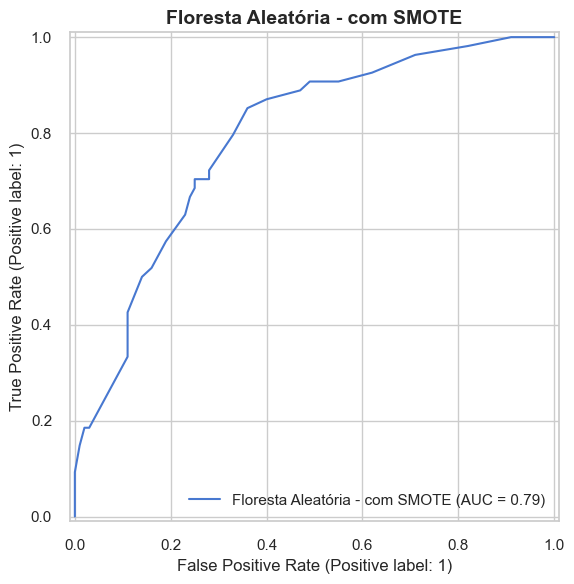

In [65]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6), dpi=100)

# Usa RocCurveDisplay do scikit-learn
RocCurveDisplay.from_estimator(
    modelo_floresta_aleatoria,
    X_test,
    y_test,
    ax=axes,
    name="Floresta Aleatória - com SMOTE"
)

axes.set_title("Floresta Aleatória - com SMOTE", fontsize=14, fontweight='bold')
axes.grid(True)

plt.tight_layout()
plt.show()

### **Avaliando a Curva ROC e AUC após o SMOTE**

O SMOTE ajudou no equilíbrio do dataset, mas causou perda na capacidade de separação do modelo.

A AUC caiu de 0,81 para 0,79. Antes o modelo tinha uma capacidade um pouco superior de distinguir as duas classes. Isso ocorreu pelo fato do SMOTE cria dados sintéticos que poluem a base e as decisões. Aquela área laranja de variância nos indicava isso.

# 6. CONCLUSÃO

O modelo **Floresta Aleatória** consolida-se como o melhor modelo em quase todas as métricas (Acurácia, AUC e F1-Score) sem SMOTE aplicado. O **KNN** mantém um segundo lugar. A **Regressão Logística** tem desempenho mediano, sendo um modelo simples e interpretável, mas que perde para os algoritmos não lineares neste conjunto de dados. A **Árvore de Decisão** tem desempenho mais baixo.

Mesmo após termos usado a técnica de SMOTE, não conseguimos elevar nossa acurácia para ficar entre 80 a 85%. Claramente o modelo sofreu com overfiting após a aplicação do SMOTE, no entanto as métricas comprovaram que sua aplicação foi benéfica o que garante mater o modelo.

Desta forma o modelo escolhido para apoiar o hospital do nosso desafio e profissionais de saúde é o modelo de **Floresta Aleatória**, demonstrando ser a arquitetura que melhor lidou com a complexidade e o ruído dos dados de diabetes.



# 7. COMPILANDO O MELHOR MODELO (SESSÃO ADICIONADA APÓS CONFECÇÃO DO VÍDEO)

Vamos treinar o random forest novamente sem o SMOTE para salvá-lo e testá-lo na prática

In [66]:
import os
import pickle

# Separand a base em treino e teste novamente sem SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Treinando o modelo novamente sem SMOTE para salvar
modelo_floresta_aleatoria_final = RandomForestClassifier(max_depth=15, max_features='log2', min_samples_leaf=1, min_samples_split=5, n_estimators=30, random_state=42)
modelo_floresta_aleatoria_final.fit(X_train, y_train)

# salvando o modelo com pickle
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)
filepath = os.path.join(models_dir, 'diabetes_random_forest_model.pkl')
with open(filepath, 'wb') as file:
    pickle.dump(modelo_floresta_aleatoria_final, file)

print(f'Modelo salvo em: {filepath}')

Modelo salvo em: ../models\diabetes_random_forest_model.pkl


# 8. TESTE DO MODELO SALVO

Nesta seção, vamos testar o modelo salvo comparando com o modelo original, realizando previsões e avaliando seu desempenho.

In [67]:

# Caminho do modelo salvo
model_path = '../models/diabetes_random_forest_model.pkl'

# Carregar o modelo
with open(model_path, 'rb') as file:
    modelo_carregado = pickle.load(file)

print(f'Modelo carregado com sucesso de: {model_path}')
print(f'Tipo do modelo: {type(modelo_carregado).__name__}')

Modelo carregado com sucesso de: ../models/diabetes_random_forest_model.pkl
Tipo do modelo: RandomForestClassifier


### Avaliar desempenho do modelo carregado

In [68]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Fazer previsões com o modelo carregado
y_pred_carregado = modelo_carregado.predict(X_test)

# Avaliar acurácia
acuracia_carregado = accuracy_score(y_test, y_pred_carregado)
print(f'Acurácia do modelo carregado: {acuracia_carregado:.4f}')
print('\n' + '='*60)

# Relatório de classificação
print('\nRelatório de Classificação:')
print(classification_report(y_test, y_pred_carregado, target_names=['Não Diabético', 'Diabético']))

# Matriz de confusão
print('\nMatriz de Confusão:')
cm = confusion_matrix(y_test, y_pred_carregado)
print(cm)

Acurácia do modelo carregado: 0.7532


Relatório de Classificação:
               precision    recall  f1-score   support

Não Diabético       0.79      0.85      0.82       100
    Diabético       0.67      0.57      0.62        54

     accuracy                           0.75       154
    macro avg       0.73      0.71      0.72       154
 weighted avg       0.75      0.75      0.75       154


Matriz de Confusão:
[[85 15]
 [23 31]]


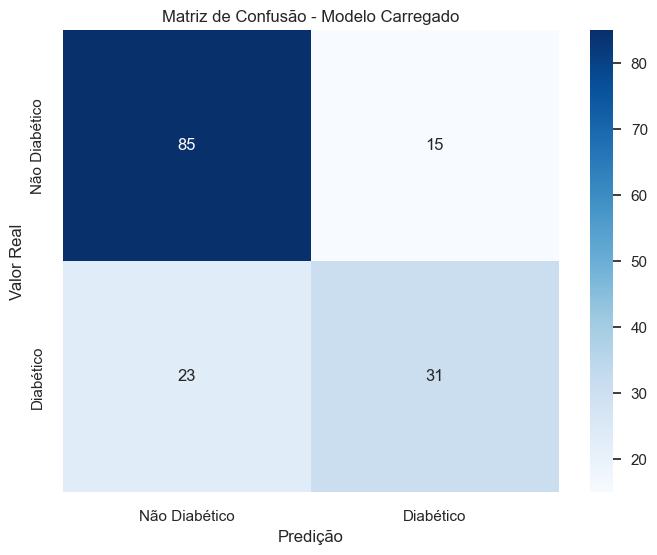

In [69]:
# Visualizar matriz de confusão
plt.figure(figsize=(8, 6))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Não Diabético', 'Diabético'],
            yticklabels=['Não Diabético', 'Diabético'])
plt.title('Matriz de Confusão - Modelo Carregado')
plt.ylabel('Valor Real')
plt.xlabel('Predição')
plt.show()

### Verificar se o modelo carregado é idêntico ao original

In [70]:
# Comparar previsões do modelo original e carregado
y_pred_original = modelo_floresta_aleatoria_final.predict(X_test)
#y_pred_carregado = modelo_carregado.predict(X_test)

# Verificar se são idênticas
previsoes_identicas = np.array_equal(y_pred_original, y_pred_carregado)

print('Comparação: Modelo Original vs Modelo Carregado')
print('='*60)
print(f'Previsões são idênticas? {previsoes_identicas}')
print(f'\nAcurácia modelo original: {accuracy_score(y_test, y_pred_original):.4f}')
print(f'Acurácia modelo carregado: {accuracy_score(y_test, y_pred_carregado):.4f}')

if previsoes_identicas:
    print('\nModelo foi salvo e carregado corretamente!')
else:
    print('\nHá diferenças entre o modelo original e o carregado.')

Comparação: Modelo Original vs Modelo Carregado
Previsões são idênticas? True

Acurácia modelo original: 0.7532
Acurácia modelo carregado: 0.7532

Modelo foi salvo e carregado corretamente!


### Testar com novos dados (exemplo)

In [71]:
# Criar alguns exemplos de novos dados para teste
# Exemplo 1: Paciente com alto risco de diabetes
exemplo_alto_risco = pd.DataFrame({
    'Pregnancies': [6],
    'Glucose': [148],
    'BloodPressure': [72],
    'SkinThickness': [35],
    'Insulin': [0],
    'BMI': [33.6],
    'DiabetesPedigreeFunction': [0.627],
    'Age': [50]
})

# Exemplo 2: Paciente com baixo risco de diabetes
exemplo_baixo_risco = pd.DataFrame({
    'Pregnancies': [1],
    'Glucose': [85],
    'BloodPressure': [66],
    'SkinThickness': [29],
    'Insulin': [0],
    'BMI': [26.6],
    'DiabetesPedigreeFunction': [0.351],
    'Age': [31]
})

# Fazer previsões
pred_alto_risco = modelo_carregado.predict(exemplo_alto_risco)[0]
prob_alto_risco = modelo_carregado.predict_proba(exemplo_alto_risco)[0]

pred_baixo_risco = modelo_carregado.predict(exemplo_baixo_risco)[0]
prob_baixo_risco = modelo_carregado.predict_proba(exemplo_baixo_risco)[0]

# Exibir resultados
print('Exemplo 1 - Paciente de Alto Risco:')
print(f'Predição: {"DIABÉTICO" if pred_alto_risco == 1 else "NÃO DIABÉTICO"}')
print(f'Probabilidade - Não Diabético: {prob_alto_risco[0]:.2%}')
print(f'Probabilidade - Diabético: {prob_alto_risco[1]:.2%}')
print('\n' + '='*60 + '\n')

print('Exemplo 2 - Paciente de Baixo Risco:')
print(f'Predição: {"DIABÉTICO" if pred_baixo_risco == 1 else "NÃO DIABÉTICO"}')
print(f'Probabilidade - Não Diabético: {prob_baixo_risco[0]:.2%}')
print(f'Probabilidade - Diabético: {prob_baixo_risco[1]:.2%}')

Exemplo 1 - Paciente de Alto Risco:
Predição: DIABÉTICO
Probabilidade - Não Diabético: 44.72%
Probabilidade - Diabético: 55.28%


Exemplo 2 - Paciente de Baixo Risco:
Predição: NÃO DIABÉTICO
Probabilidade - Não Diabético: 94.72%
Probabilidade - Diabético: 5.28%


### Função para fazer previsão com novos dados

In [72]:
def prever_diabetes(modelo, pregnancies, glucose, blood_pressure, skin_thickness, 
                   insulin, bmi, diabetes_pedigree, age):
    """
    Função para prever se um paciente tem diabetes
    
    Parâmetros:
    -----------
    modelo : modelo treinado
    pregnancies : número de gestações
    glucose : nível de glicose
    blood_pressure : pressão arterial
    skin_thickness : espessura da pele
    insulin : nível de insulina
    bmi : índice de massa corporal
    diabetes_pedigree : função de pedigree de diabetes
    age : idade
    
    Retorna:
    --------
    predição e probabilidades
    """
    # Criar dataframe com os dados
    dados = pd.DataFrame({
        'Pregnancies': [pregnancies],
        'Glucose': [glucose],
        'BloodPressure': [blood_pressure],
        'SkinThickness': [skin_thickness],
        'Insulin': [insulin],
        'BMI': [bmi],
        'DiabetesPedigreeFunction': [diabetes_pedigree],
        'Age': [age]
    })
    
    # Fazer previsão
    predicao = modelo.predict(dados)[0]
    probabilidades = modelo.predict_proba(dados)[0]
    
    # Exibir resultados
    print('='*60)
    print('RESULTADO DA PREVISÃO')
    print('='*60)
    print(f'\nDados do Paciente:')
    print(f'  - Gestações: {pregnancies}')
    print(f'  - Glicose: {glucose}')
    print(f'  - Pressão Arterial: {blood_pressure}')
    print(f'  - Espessura da Pele: {skin_thickness}')
    print(f'  - Insulina: {insulin}')
    print(f'  - IMC: {bmi}')
    print(f'  - Função Pedigree: {diabetes_pedigree}')
    print(f'  - Idade: {age}')
    print(f'\nPredição: {"DIABÉTICO ⚠️" if predicao == 1 else "NÃO DIABÉTICO ✓"}')
    print(f'\nProbabilidades:')
    print(f'  - Não Diabético: {probabilidades[0]:.2%}')
    print(f'  - Diabético: {probabilidades[1]:.2%}')
    print('='*60)
    
    return predicao, probabilidades

# Exemplo de uso
prever_diabetes(modelo_carregado, 
               pregnancies=2, 
               glucose=120, 
               blood_pressure=70, 
               skin_thickness=30, 
               insulin=100, 
               bmi=28.5, 
               diabetes_pedigree=0.45, 
               age=35)

RESULTADO DA PREVISÃO

Dados do Paciente:
  - Gestações: 2
  - Glicose: 120
  - Pressão Arterial: 70
  - Espessura da Pele: 30
  - Insulina: 100
  - IMC: 28.5
  - Função Pedigree: 0.45
  - Idade: 35

Predição: NÃO DIABÉTICO ✓

Probabilidades:
  - Não Diabético: 57.01%
  - Diabético: 42.99%


(np.int64(0), array([0.570116, 0.429884]))